In [1]:
  # connect with Google Drive:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns',None)

In [3]:
df_customer = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data set/Movie_ticket_Capstone Project/movie_ticket_data/customer.csv')
df_ticket = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data set/Movie_ticket_Capstone Project/movie_ticket_data/ticket_history.csv')
df_device = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data set/Movie_ticket_Capstone Project/movie_ticket_data/device_detail.csv')
df_status = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data set/Movie_ticket_Capstone Project/movie_ticket_data/status_detail.csv')
df_campaign = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data set/Movie_ticket_Capstone Project/movie_ticket_data/campaign.csv')

**2.Data cleaning:**

**2.1 Data type, NULL values, Duplicate values**

In [4]:
# Bảng customer
df_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131400 entries, 0 to 131399
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   customer_id  131400 non-null  int64 
 1   usergender   131400 non-null  object
 2   dob          131400 non-null  object
dtypes: int64(1), object(2)
memory usage: 3.0+ MB


In [5]:
df_customer.head(2)

,customer_id,usergender,dob
0,100032,Female,8/8/1985
1,100046,Male,7/11/1987


In [6]:
# Chuyển đổi data type của dob thành datetime
from datetime import datetime
df_customer['dob'] = pd.to_datetime(df_customer['dob'])

In [7]:
df_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131400 entries, 0 to 131399
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   customer_id  131400 non-null  int64         
 1   usergender   131400 non-null  object        
 2   dob          131400 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 3.0+ MB


In [8]:
df_customer['customer_id'].nunique()

131400

In [9]:
# Bảng campaign
df_campaign.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216 entries, 0 to 215
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   campaign_id    216 non-null    int64 
 1   campaign_type  216 non-null    object
dtypes: int64(1), object(1)
memory usage: 3.5+ KB


In [10]:
df_campaign.head(2)

,campaign_id,campaign_type
0,106460,direct discount
1,30040,direct discount


In [11]:
df_campaign['campaign_id'].nunique()

216

In [12]:
# Bảng Device
df_device.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139902 entries, 0 to 139901
Data columns (total 3 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   device_number  139901 non-null  object
 1   model          132763 non-null  object
 2   platform       139902 non-null  object
dtypes: object(3)
memory usage: 3.2+ MB


In [13]:
# Create func calculate NULL rate of each column
def calc_null_rate(df):
    newdf = df.isnull().sum().to_frame('null_count')
    newdf[['null_rate']] = newdf[['null_count']] / len(df)
    return newdf.sort_values(by=['null_rate'], ascending=False)

In [14]:
calc_null_rate(df_device)

,null_count,null_rate
model,7139,0.051029
device_number,1,0.000007
platform,0,0.000000


In [15]:
# 1 Thay thế NULL trong model thành 'unknown'
# 2 Xóa giá trị NULL tỏng cột device_number
df_device = df_device.fillna({'model':'unknown'})
df_device = df_device[df_device['device_number'].notna()]

In [16]:
calc_null_rate(df_device)

,null_count,null_rate
device_number,0,0.0
model,0,0.0
platform,0,0.0


In [17]:
# Bảng Status
df_status.head(10)

,status_id,description,error_group
0,1,Order successful,NaN
1,-1,Payment overdue,customer
2,-2,Insufficient funds in customer account. Please add more funds and try the transaction again.,customer
3,-3,No response from your bank,external
4,-4,Password locked due to multiple incorrect attempts. Choose Forgot Password to unlock.,customer
5,-5,Payment failed from bank,external
6,-6,Need verify your account to continue,customer
7,-7,Transaction temporarily limited,internal


In [18]:
# Bảng ticket
df_ticket.head(2)

,ticket_id,customer_id,paying_method,theater_name,device_number,original_price,discount_value,final_price,time,status_id,campaign_id,movie_name
0,4f5200dcdcf2396b8d50ff84bf423f32,100009,money in app,13.0,244764a57dbdeb8fe9b164847ad55183,9.90,2.10,7.80,2022-07-08 17:46:36.145,1,83330,Thor: Love And Thunder
1,07abbaf28c772692f0367ad992bb3184,100493,bank account,180.0,8fa83cf46284aafd6e5da6c96f7862b5,8.66,1.48,7.18,2022-07-15 20:44:09.952,1,83330,Thor: Love And Thunder


In [19]:
df_ticket.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 154827 entries, 0 to 154826
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   ticket_id       154827 non-null  object 
 1   customer_id     154827 non-null  int64  
 2   paying_method   154827 non-null  object 
 3   theater_name    154827 non-null  float64
 4   device_number   154827 non-null  object 
 5   original_price  154827 non-null  float64
 6   discount_value  154827 non-null  float64
 7   final_price     154827 non-null  float64
 8   time            154827 non-null  object 
 9   status_id       154827 non-null  int64  
 10  campaign_id     154827 non-null  int64  
 11  movie_name      154827 non-null  object 
dtypes: float64(4), int64(3), object(5)
memory usage: 14.2+ MB


In [20]:
# Thay đổi datatype của cột TIME

In [21]:
df_ticket['time'] = pd.to_datetime(df_ticket['time'])

In [22]:
calc_null_rate(df_ticket)

,null_count,null_rate
ticket_id,0,0.0
customer_id,0,0.0
paying_method,0,0.0
theater_name,0,0.0
device_number,0,0.0
original_price,0,0.0
discount_value,0,0.0
final_price,0,0.0
time,0,0.0
status_id,0,0.0


In [23]:
df_ticket['ticket_id'].nunique()

154725

In [24]:
154827-154725

102

In [25]:
df_dup = df_ticket[df_ticket.duplicated(keep = False)]

In [26]:
df_dup.head(10)

,ticket_id,customer_id,paying_method,theater_name,device_number,original_price,discount_value,final_price,time,status_id,campaign_id,movie_name
3555,c56e3eb9fb1fd241c9de7a700d7a52d2,206709,money in app,5.0,291f6a5c77b7d98a86fe76bdbabe94eb,5.77,1.03,4.74,2022-07-02 22:11:30.005,1,85940,Thor: Love And Thunder
3556,c56e3eb9fb1fd241c9de7a700d7a52d2,206709,money in app,5.0,291f6a5c77b7d98a86fe76bdbabe94eb,5.77,1.03,4.74,2022-07-02 22:11:30.005,1,85940,Thor: Love And Thunder
49730,763e20c9c1136c5c06d9a960fac9dae6,174180,credit card,29.0,ba5794fca2cba47fd0141dd3fb195934,7.42,0.00,7.42,2019-12-23 15:28:45.738,1,0,Dreamy Eyes
49731,763e20c9c1136c5c06d9a960fac9dae6,174180,credit card,29.0,ba5794fca2cba47fd0141dd3fb195934,7.42,0.00,7.42,2019-12-23 15:28:45.738,1,0,Dreamy Eyes
49876,257d0a0e6a7f38b90b5ecdfa9e8416b9,133912,money in app,119.0,18abc497c03f7e6bd0b0cf72a89fb911,7.42,0.00,7.42,2019-12-23 18:04:51.790,1,0,Dreamy Eyes
49877,257d0a0e6a7f38b90b5ecdfa9e8416b9,133912,money in app,119.0,18abc497c03f7e6bd0b0cf72a89fb911,7.42,0.00,7.42,2019-12-23 18:04:51.790,1,0,Dreamy Eyes
50202,6dec59a668243f07301d5bf3c2368fa0,111474,debit card,109.0,a07a8e335cc40b1e39e2d7fc9a9af557,8.66,0.00,8.66,2019-12-23 10:35:45.542,1,0,Dreamy Eyes
50203,6dec59a668243f07301d5bf3c2368fa0,111474,debit card,109.0,a07a8e335cc40b1e39e2d7fc9a9af557,8.66,0.00,8.66,2019-12-23 10:35:45.542,1,0,Dreamy Eyes
50212,5f377be63fca730d5b5d12e06ac3f05d,117355,credit card,53.0,9092a5b635cbcf89633ff48766bc04e6,7.84,0.00,7.84,2019-12-23 19:30:23.767,1,0,Dreamy Eyes
50213,5f377be63fca730d5b5d12e06ac3f05d,117355,credit card,53.0,9092a5b635cbcf89633ff48766bc04e6,7.84,0.00,7.84,2019-12-23 19:30:23.767,1,0,Dreamy Eyes


In [27]:
df_ticket.drop_duplicates(inplace = True)

In [28]:
df_ticket.info()

<class 'pandas.core.frame.DataFrame'>
Index: 154725 entries, 0 to 154826
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   ticket_id       154725 non-null  object        
 1   customer_id     154725 non-null  int64         
 2   paying_method   154725 non-null  object        
 3   theater_name    154725 non-null  float64       
 4   device_number   154725 non-null  object        
 5   original_price  154725 non-null  float64       
 6   discount_value  154725 non-null  float64       
 7   final_price     154725 non-null  float64       
 8   time            154725 non-null  datetime64[ns]
 9   status_id       154725 non-null  int64         
 10  campaign_id     154725 non-null  int64         
 11  movie_name      154725 non-null  object        
dtypes: datetime64[ns](1), float64(4), int64(3), object(4)
memory usage: 15.3+ MB


**2.2 Join tables**

In [29]:
# Xuất phát từ bảng ticket để join với các bảng dimension còn lại
df_join_customer =pd.merge(df_ticket, df_customer, how = 'left', on = 'customer_id')
df_join_campaign = pd.merge(df_join_customer, df_campaign, how = 'left', on = 'campaign_id')
df_join_status = pd.merge(df_join_campaign, df_status, how = 'left', on = 'status_id')
df_join_all = pd.merge(df_join_status, df_device, how = 'left', on = 'device_number')


In [30]:
df_join_all.count()

,0
ticket_id,154725
customer_id,154725
paying_method,154725
theater_name,154725
device_number,154725
original_price,154725
discount_value,154725
final_price,154725
time,154725
status_id,154725


In [31]:
df_join_all.head(2)

,ticket_id,customer_id,paying_method,theater_name,device_number,original_price,discount_value,final_price,time,status_id,campaign_id,movie_name,usergender,dob,campaign_type,description,error_group,model,platform
0,4f5200dcdcf2396b8d50ff84bf423f32,100009,money in app,13.0,244764a57dbdeb8fe9b164847ad55183,9.90,2.10,7.80,2022-07-08 17:46:36.145,1,83330,Thor: Love And Thunder,Male,1989-02-25,direct discount,Order successful,NaN,"iPhone13,1",mobile
1,07abbaf28c772692f0367ad992bb3184,100493,bank account,180.0,8fa83cf46284aafd6e5da6c96f7862b5,8.66,1.48,7.18,2022-07-15 20:44:09.952,1,83330,Thor: Love And Thunder,Male,1991-06-09,direct discount,Order successful,NaN,browser,website


In [32]:
calc_null_rate(df_join_all)

,null_count,null_rate
error_group,133679,0.863978
campaign_type,63098,0.407807
platform,78,0.000504
model,78,0.000504
paying_method,0,0.000000
ticket_id,0,0.000000
customer_id,0,0.000000
theater_name,0,0.000000
device_number,0,0.000000
original_price,0,0.000000


In [33]:
df_join_all = df_join_all .fillna('unknown')

In [34]:
calc_null_rate(df_join_all)

,null_count,null_rate
ticket_id,0,0.0
customer_id,0,0.0
paying_method,0,0.0
theater_name,0,0.0
device_number,0,0.0
original_price,0,0.0
discount_value,0,0.0
final_price,0,0.0
time,0,0.0
status_id,0,0.0


**2.3 View All Values of each columns**

In [35]:
df_join_all.nunique().sort_values(ascending = False)

,0
ticket_id,154725
time,154725
device_number,126459
customer_id,119477
dob,11322
final_price,2715
original_price,1895
model,1215
movie_name,253
discount_value,242


In [36]:
specific_cols = ['movie_name','description','paying_method','campaign_type','usergender','platform', 'error_group']
for col in specific_cols:
    print(col + ' : ', np.sort(df_join_all[col].unique().astype(str)))
    print('\r')
    print('--------------------------')
    print('\r')

movie_name :  ['13rd Sister' '13rd Sister: Three Deadly Days' '1990' '2037'
 '30 Chua Phai Tet' '47 Meters Down: Uncaged' 'A Chamada Da Selva'
 'A Diamond In The Rough' 'Accidentally Dad' 'Aladdin' 'Alienoid'
 'Alita: Battle Angel' 'Ambulance' 'Anchor' 'Angel Has Fallen' 'Anna'
 'Annabelle Comes Home' 'Aquaman' 'Around The World In 80 Days'
 'Autumn Promise' 'Avatar' 'Avatar: The Way Of Water' 'Avengers: Endgame'
 'Bad Boys For Life' 'Batman' 'Beast' 'Birds Of Prey' 'Black Adam'
 'Black Panther 2: Wakanda Forever' 'Black Panther: Wakanda Forever'
 'Blood Karma' 'Blood Moon Party' 'Bloodshot' 'Broker' 'Bullet Train'
 'Bumblebee' 'Bắc Kim Thang' 'Camellia Sisters' 'Captain Marvel'
 "Charlie's Angels" 'Cherry Magic The Movie Thirty Years'
 'Chickenhare And The Hamster Of Darkness' 'Chuyện Ma Đô Thị' 'Collectors'
 'Concessions' 'Confidential Assignment 2: International' 'Cracked'
 'Crawl' 'Crazy Romance' "Dad I'm Sorry" 'Daddy Issues' 'Daeng'
 'Dark Figure Of Crime' 'Dc League Of Super-Pet

**3.Analyze**

**3.1 Customer portrait**

**Age and gender distribution**





In [37]:
df_join_all.head(2)

,ticket_id,customer_id,paying_method,theater_name,device_number,original_price,discount_value,final_price,time,status_id,campaign_id,movie_name,usergender,dob,campaign_type,description,error_group,model,platform
0,4f5200dcdcf2396b8d50ff84bf423f32,100009,money in app,13.0,244764a57dbdeb8fe9b164847ad55183,9.90,2.10,7.80,2022-07-08 17:46:36.145,1,83330,Thor: Love And Thunder,Male,1989-02-25,direct discount,Order successful,unknown,"iPhone13,1",mobile
1,07abbaf28c772692f0367ad992bb3184,100493,bank account,180.0,8fa83cf46284aafd6e5da6c96f7862b5,8.66,1.48,7.18,2022-07-15 20:44:09.952,1,83330,Thor: Love And Thunder,Male,1991-06-09,direct discount,Order successful,unknown,browser,website


In [38]:
# Tính số tuổi
current_date = datetime.now()
df_join_all['age_days'] = (current_date - df_join_all['dob']).dt.days
df_join_all['age'] = df_join_all['age_days'] / 365.25
df_join_all['age'] = df_join_all['age'].astype(int)

In [39]:
# Lấy ra ds KH kèm theo age và gender
df_cus = df_join_all.drop_duplicates(subset = ['customer_id'])[['customer_id','dob','age', 'usergender']]

In [40]:
df_cus.count()

,0
customer_id,119477
dob,119477
age,119477
usergender,119477


In [41]:
df_cus.head(2)

,customer_id,dob,age,usergender
0,100009,1989-02-25,37,Male
1,100493,1991-06-09,35,Male


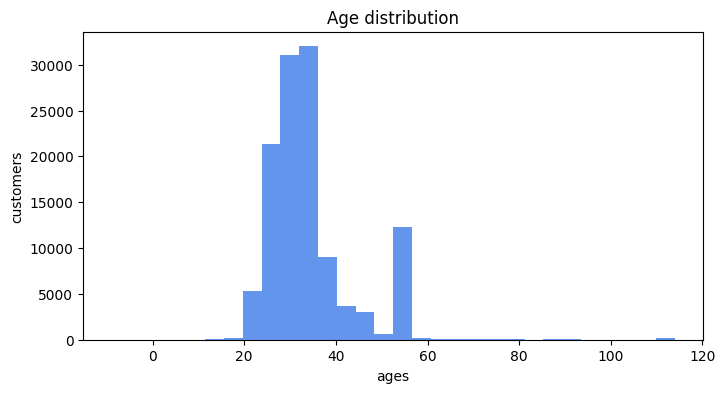

In [42]:
# Phân bổ khách hàng theo độ tuổi
plt.figure(figsize = (8,4))
df_cus['age'].hist(bins = 30, color ='cornflowerblue',grid = False)
plt.xlabel('ages')
plt.ylabel('customers')
plt.title('Age distribution')
plt.show()

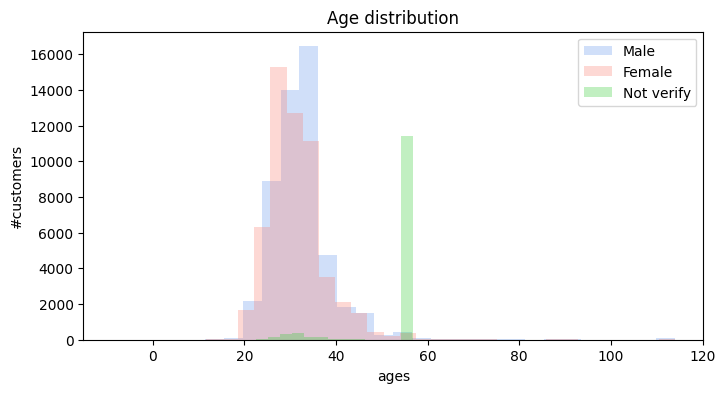

In [43]:
# Phân bổ độ tuổi theo nhóm giới tính :
plt.figure(figsize=(8,4))

## data
male_age = df_cus[df_cus['usergender'] == 'Male']['age']
female_age = df_cus[df_cus['usergender'] == 'Female']['age']
unknown_age = df_cus[df_cus['usergender'] == 'Not verify']['age']

## plot
plt.hist(male_age, bins=30, alpha = 0.3, color = 'cornflowerblue', label = 'Male')
plt.hist(female_age, bins=30, alpha = 0.3, color = 'salmon', label = 'Female')
plt.hist(unknown_age, bins=30, alpha = 0.3, color = 'limegreen', label = 'Not verify')

##edit
plt.title('Age distribution')
plt.xlabel('ages')
plt.ylabel('#customers')
plt.legend()
plt.show()

In [44]:
# Đánh giá chi tiết nhóm Not Verify
df_gen = df_cus.groupby('usergender').agg(total = ('customer_id','count')).sort_values(by = 'total', ascending = False).reset_index()

In [45]:
df_gen

,usergender,total
0,Female,55689
1,Male,50873
2,Not verify,12915


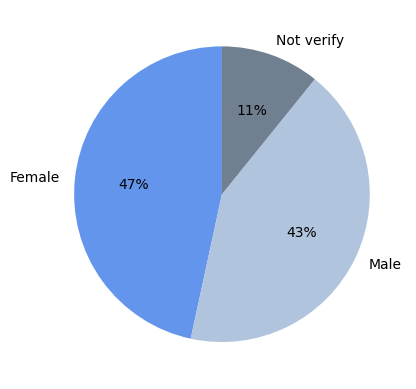

In [46]:
# Visualize
plt.pie(df_gen['total'], labels = df_gen['usergender'], colors = ['cornflowerblue', 'lightsteelblue', 'slategrey'], autopct = '%1.0f%%', startangle=90)
plt.show()

In [47]:
df_cus[df_cus['usergender']=='Not verify'].groupby('age').agg(number =('customer_id','count')).reset_index().sort_values(by = 'number', ascending = False).head(10)

,age,number
39,56,11435
14,31,124
13,30,118
11,28,117
15,32,116
16,33,110
12,29,106
17,34,101
10,27,92
19,36,88


**Note**
Nhóm KH chưa verify tài khoản chiếm hơn 11%. Dẫn tới 2 trường hợp:

 * Nếu họ nhập dob thì sẽ có data
 * Nếu họ không nhập thì hệ thống sẽ auto fill là 1970 -> 56 tuổi



**Age generation distribution**

In [48]:
df_cus.head(2)

,customer_id,dob,age,usergender
0,100009,1989-02-25,37,Male
1,100493,1991-06-09,35,Male


In [49]:
# Logic phân loại X, Y, Z, Baby Boomers -> Dựa vào năm sinh
df_cus['age_generation'] = df_cus['dob'].apply(lambda x: 'baby boomers' if x.year < 1965 else 'gen X' if x.year < 1981 else 'gen Y' if x.year < 1997 else 'gen Z')

In [50]:
df_gen_group = df_cus[df_cus['usergender'] != 'Not verify'].groupby('age_generation').agg(
    total = ('customer_id', 'count')
).sort_values(by = 'total', ascending = False).reset_index()

In [51]:
df_gen_group

,age_generation,total
0,gen Y,63310
1,gen Z,38401
2,gen X,4261
3,baby boomers,590


In [52]:
# Kết hợp 2 biểu đồ cùng lúc:
plt.figure(figsize = (13,4))
# plot 1



<Figure size 1300x400 with 0 Axes>

<Figure size 1300x400 with 0 Axes>

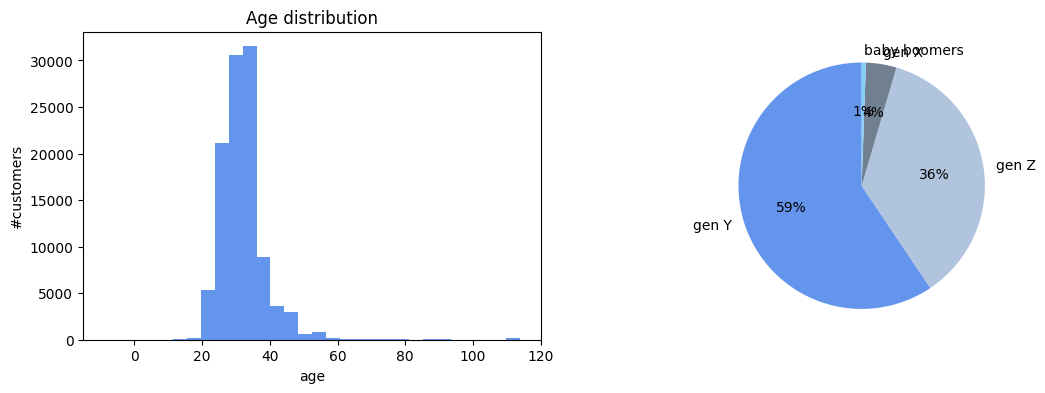

In [53]:
plt.figure(figsize = (13,4))
# plot 1

ax1 = plt.subplot(1,2,1)
df_cus[df_cus['usergender'] !='Not verify']['age'].hist(bins = 30, color ='cornflowerblue', grid = False)
plt.xlabel('age')
plt.ylabel('#customers')
plt.title('Age distribution')

ax2 = plt.subplot(1,2,2)
plt.pie(df_gen_group['total'], labels = df_gen_group['age_generation'],colors = ['cornflowerblue', 'lightsteelblue', 'slategrey','lightskyblue'], autopct = '%1.0f%%', startangle=90)
plt.show()

**3.2 Time series data - When did customers buy tickets ?**

**Trend by month**

In [54]:
df_join_all.head(2)

,ticket_id,customer_id,paying_method,theater_name,device_number,original_price,discount_value,final_price,time,status_id,campaign_id,movie_name,usergender,dob,campaign_type,description,error_group,model,platform,age_days,age
0,4f5200dcdcf2396b8d50ff84bf423f32,100009,money in app,13.0,244764a57dbdeb8fe9b164847ad55183,9.90,2.10,7.80,2022-07-08 17:46:36.145,1,83330,Thor: Love And Thunder,Male,1989-02-25,direct discount,Order successful,unknown,"iPhone13,1",mobile,13730,37
1,07abbaf28c772692f0367ad992bb3184,100493,bank account,180.0,8fa83cf46284aafd6e5da6c96f7862b5,8.66,1.48,7.18,2022-07-15 20:44:09.952,1,83330,Thor: Love And Thunder,Male,1991-06-09,direct discount,Order successful,unknown,browser,website,12896,35


In [55]:
df_join_all['month'] = pd.to_datetime(df_join_all['time']).dt.month
df_join_all['name_day'] = pd.to_datetime(df_join_all['time']).dt.day_name()
df_join_all['hour'] = pd.to_datetime(df_join_all['time']).dt.hour
df_join_all['year_month'] =(df_join_all['time']).dt.strftime('%Y-%m')

In [56]:
# Thống kê theo tháng
df_time_month = (
    df_join_all.groupby('year_month').agg(total_ticket = ('ticket_id', 'count')).reset_index()
 )

In [57]:
df_time_month.head(10)

,year_month,total_ticket
0,2019-01,2019
1,2019-02,1626
2,2019-03,1004
3,2019-04,4069
4,2019-05,4430
5,2019-06,4387
6,2019-07,3872
7,2019-08,5444
8,2019-09,3278
9,2019-10,5284


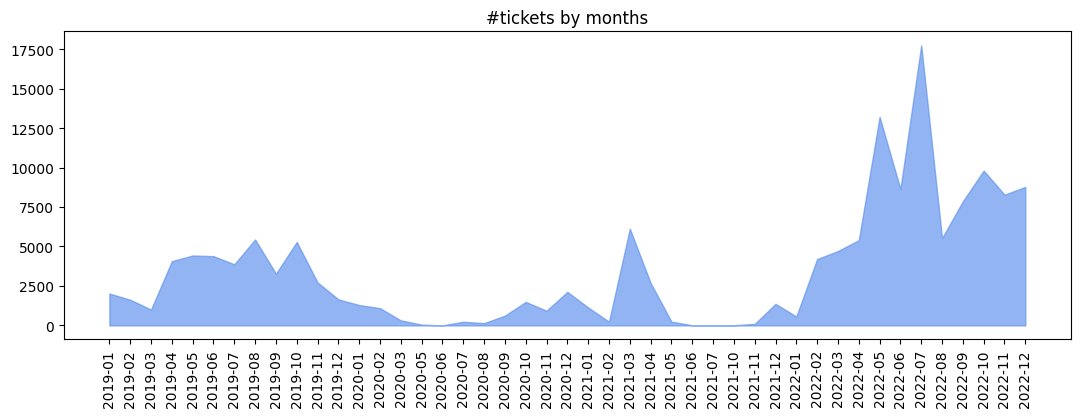

In [58]:
1# Vễ biểu đồ miền theo tháng:
plt.figure(figsize=(13,4))
plt.fill_between(df_time_month['year_month'], df_time_month['total_ticket'],color = 'cornflowerblue',alpha = 0.7)
plt.title('#tickets by months')
plt.xticks(rotation = 90)
plt.show()

In [59]:
# Giai đoạn covid diễn ra -> người ta ko đi xem phim
# Để show ra các tháng k có dữ liệu -> Cần 1 bảng Dim thời gian theo tháng (FULL)

In [60]:
# Tạo bảng DIM về time để JOIN lại với data ticket và vẽ lại chart

In [61]:
# Tạo bảng dimension thời gian:

# Xác định khoảng thời gian
start_date = '2019-01-01'
end_date = '2022-12-31'

# Tạo ra range thời gian từ 2 mốc start và end
date_range = pd.date_range(start=start_date, end=end_date, freq='MS')

# Lấy ra list phần tử thời gian tương ứng:
list_month = date_range.month
list_month_name = date_range.strftime('%B')
list_year = date_range.year
list_year_month = date_range.strftime('%Y-%m')

# # Khởi tạo dataframe
dim_time = pd.DataFrame({
    'month_number': list_month,
    'month_name': list_month_name,
    'year': list_year,
    'year_month': list_year_month
})

In [62]:
dim_time

,month_number,month_name,year,year_month
0,1,January,2019,2019-01
1,2,February,2019,2019-02
2,3,March,2019,2019-03
3,4,April,2019,2019-04
4,5,May,2019,2019-05
5,6,June,2019,2019-06
6,7,July,2019,2019-07
7,8,August,2019,2019-08
8,9,September,2019,2019-09
9,10,October,2019,2019-10


In [63]:
# JOIN với bảng df_join_all để mình có đủ data thời gian
df_time_month_dim = (
    pd.merge(dim_time, df_join_all, how = 'left', on='year_month')
    .groupby('year_month')
    .agg(total_ticket = ('ticket_id','count'))
    .reset_index()
)

In [64]:
df_time_month_dim.replace(0, np.nan, inplace= True)

In [65]:
df_time_month_dim

,year_month,total_ticket
0,2019-01,2019.0
1,2019-02,1626.0
2,2019-03,1004.0
3,2019-04,4069.0
4,2019-05,4430.0
5,2019-06,4387.0
6,2019-07,3872.0
7,2019-08,5444.0
8,2019-09,3278.0
9,2019-10,5284.0


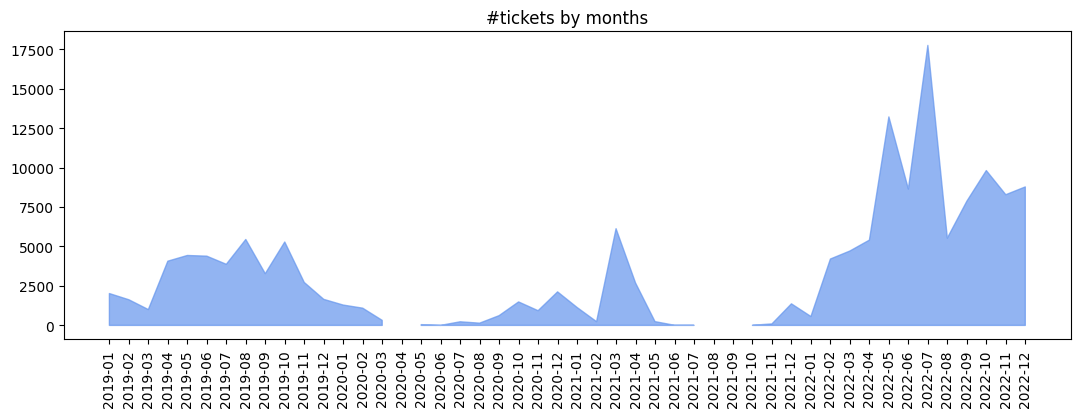

In [66]:
1# Vễ biểu đồ miền theo tháng:
plt.figure(figsize=(13,4))
plt.fill_between(df_time_month_dim['year_month'], df_time_month_dim['total_ticket'],color = 'cornflowerblue',alpha = 0.7)
plt.title('#tickets by months')
plt.xticks(rotation = 90)
plt.show()

**Trend by week days**

In [67]:
# Thống kê theo ngày trong tuần
df_week_day = (
    df_join_all
    .groupby(['name_day']).agg(total_ticket =( 'ticket_id', 'count')).reset_index()
)

In [68]:
df_week_day

,name_day,total_ticket
0,Friday,26438
1,Monday,16702
2,Saturday,34450
3,Sunday,26960
4,Thursday,19101
5,Tuesday,14793
6,Wednesday,16281


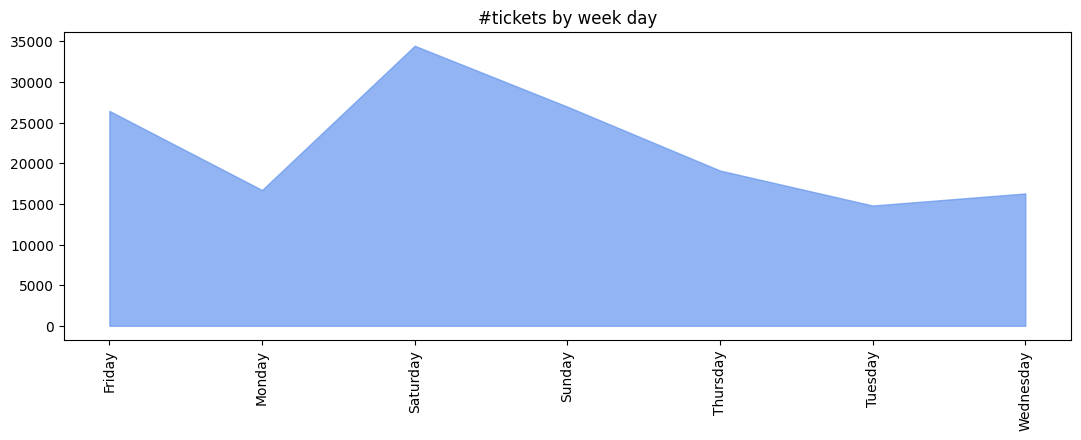

In [69]:
1# Vễ biểu đồ miền theo tháng:
plt.figure(figsize=(13,4))
plt.fill_between(df_week_day['name_day'], df_week_day['total_ticket'],color = 'cornflowerblue',alpha = 0.7)
plt.title('#tickets by week day')
plt.xticks(rotation = 90)
plt.show()

In [70]:
# Định nghĩa thứ tự của các ngày trong tuần
week_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Sắp xếp theo thứ tự các ngày trong tuần
df_week_day['day_order'] = pd.Categorical(df_week_day['name_day'], categories=week_order, ordered = True)
df_week_day.sort_values('day_order', inplace = True)


In [71]:
df_week_day

,name_day,total_ticket,day_order
1,Monday,16702,Monday
5,Tuesday,14793,Tuesday
6,Wednesday,16281,Wednesday
4,Thursday,19101,Thursday
0,Friday,26438,Friday
2,Saturday,34450,Saturday
3,Sunday,26960,Sunday


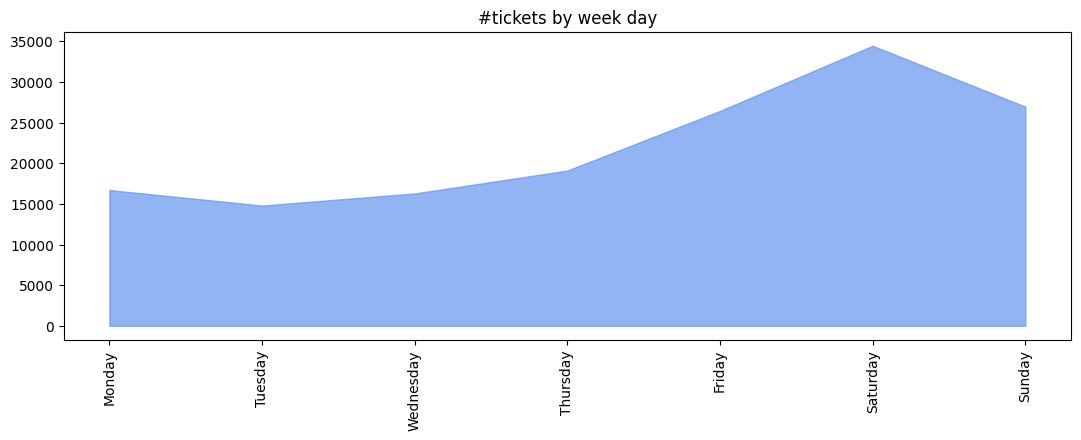

In [72]:
1# Vễ biểu đồ miền theo tháng:
plt.figure(figsize=(13,4))
plt.fill_between(df_week_day['name_day'], df_week_day['total_ticket'],color = 'cornflowerblue',alpha = 0.7)
plt.title('#tickets by week day')
plt.xticks(rotation = 90)
plt.show()

**Trend by hours**

In [73]:
# Thống kê theo giờ
df_hour = (
    df_join_all
    .groupby(['hour']).agg(total_ticket =( 'ticket_id', 'count')).reset_index()
)

In [74]:
df_hour

,hour,total_ticket
0,0,2352
1,1,964
2,2,398
3,3,159
4,4,74
5,5,146
6,6,536
7,7,1473
8,8,3865
9,9,7111


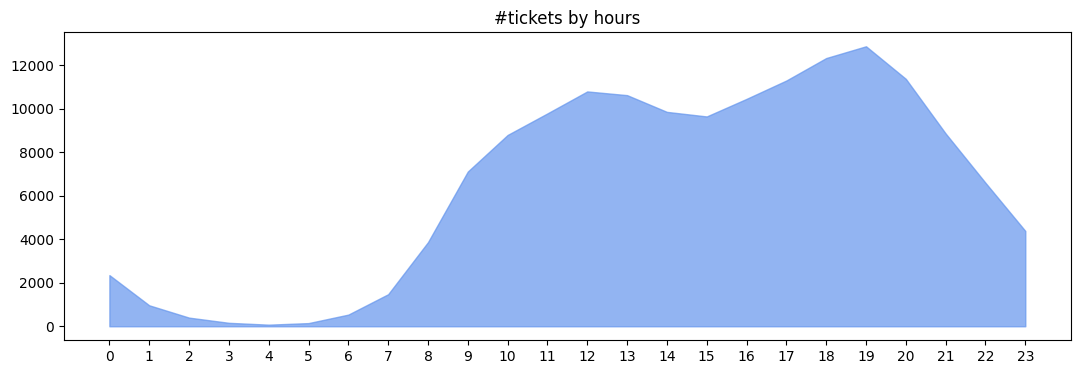

In [75]:
1# Vễ biểu đồ miền theo giờj:
plt.figure(figsize=(13,4))
plt.fill_between(df_hour['hour'], df_hour['total_ticket'],color = 'cornflowerblue',alpha = 0.7)
x_values = [i for i in range(24)]
plt.xticks(x_values)
plt.title('#tickets by hours')
plt.show()

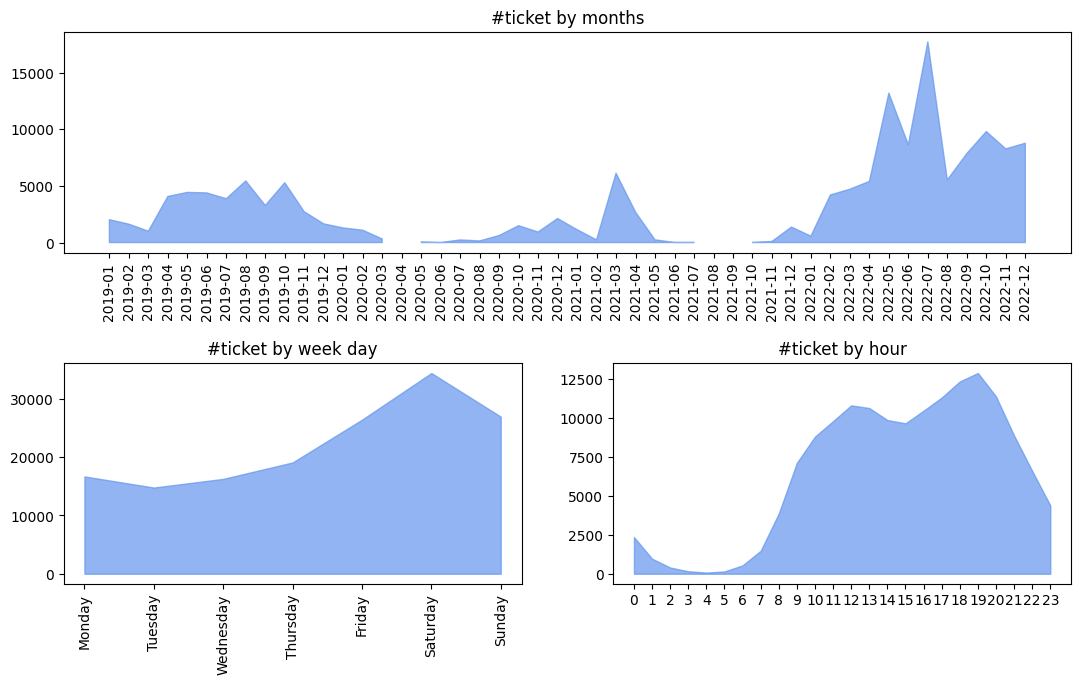

In [76]:
# Vẽ chung trên 1 frame :
plt.figure(figsize=(13, 8))

# chart 1: Tháng
ax1 = plt.subplot(2, 1, 1)
plt.fill_between(df_time_month_dim['year_month'], df_time_month_dim['total_ticket'], color = 'cornflowerblue', alpha=0.7)
plt.title('#ticket by months')
plt.xticks(rotation=90)

# chart 2: ngày
ax2 = plt.subplot(2, 2, 3)
plt.fill_between(df_week_day['name_day'], df_week_day['total_ticket'], color = 'cornflowerblue', alpha=0.7)
plt.title('#ticket by week day')
plt.xticks(rotation=90)

# chart 3: giờ
ax3 = plt.subplot(2, 2, 4)
plt.fill_between(df_hour['hour'], df_hour['total_ticket'], color = 'cornflowerblue', alpha=0.7)
x_values = [i for i in range(24)]
plt.xticks(x_values)
plt.title('#ticket by hour')

plt.subplots_adjust( hspace = 0.5, top=0.8)

**3.3 Factors related to the customer's purchasing process**

**Payment platform**

In [77]:
df_join_all.head(2)

,ticket_id,customer_id,paying_method,theater_name,device_number,original_price,discount_value,final_price,time,status_id,campaign_id,movie_name,usergender,dob,campaign_type,description,error_group,model,platform,age_days,age,month,name_day,hour,year_month
0,4f5200dcdcf2396b8d50ff84bf423f32,100009,money in app,13.0,244764a57dbdeb8fe9b164847ad55183,9.90,2.10,7.80,2022-07-08 17:46:36.145,1,83330,Thor: Love And Thunder,Male,1989-02-25,direct discount,Order successful,unknown,"iPhone13,1",mobile,13730,37,7,Friday,17,2022-07
1,07abbaf28c772692f0367ad992bb3184,100493,bank account,180.0,8fa83cf46284aafd6e5da6c96f7862b5,8.66,1.48,7.18,2022-07-15 20:44:09.952,1,83330,Thor: Love And Thunder,Male,1991-06-09,direct discount,Order successful,unknown,browser,website,12896,35,7,Friday,20,2022-07


In [78]:
df_platform =(
    df_join_all[df_join_all['platform'] != 'unknown'].groupby(['platform'])
    .agg(total_tickets = ('ticket_id', 'count'))
).reset_index()

In [79]:
df_platform

,platform,total_tickets
0,mobile,138136
1,website,16511


Text(0.5, 1.0, '#ticket by platforms')

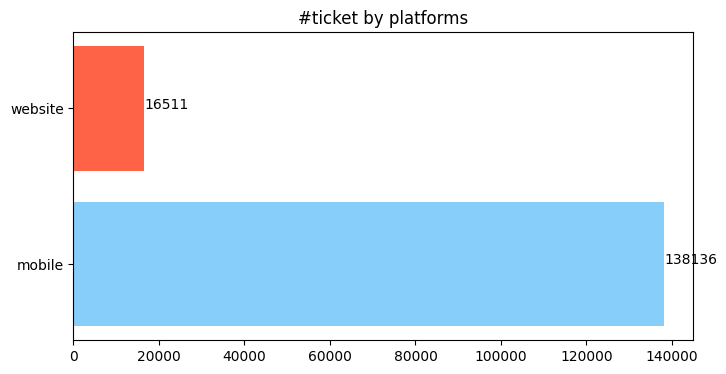

In [80]:
# Biểu đồ cột ngang :
plt.figure(figsize =(8,4))
plt.barh(
    df_platform['platform'] ,df_platform['total_tickets']
    ,color = df_platform['platform'].replace({'mobile':'lightskyblue','website':'tomato'})
)
for index,value in enumerate(df_platform['total_tickets']):
    plt.text(value,index,str(value))

plt.title('#ticket by platforms')

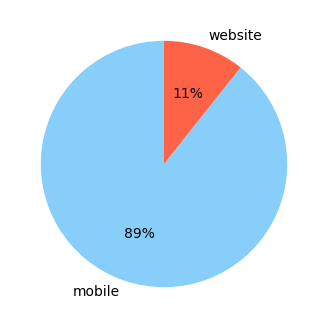

In [81]:
plt.figure(figsize=(6,4))
plt.pie(df_platform['total_tickets'], labels =df_platform['platform'], colors =df_platform['platform'].replace({'mobile':'lightskyblue','website':'tomato'}), autopct = '%1.0f%%', startangle = 90 )
plt.show()

In [82]:
# Theo thời gian
df_platform_time=(
    df_join_all[df_join_all['platform'] != 'unknown']
    .groupby(['year_month','platform'])
    .agg(total_tickets = ('ticket_id', 'count'))
    .sort_values(by ='year_month',ascending = True).reset_index()
)

In [83]:
df_platform_time.head(10)

,year_month,platform,total_tickets
0,2019-01,mobile,2019
1,2019-02,mobile,1626
2,2019-03,mobile,1004
3,2019-04,mobile,4069
4,2019-05,mobile,4430
5,2019-06,mobile,4387
6,2019-07,mobile,3872
7,2019-08,mobile,5444
8,2019-09,mobile,3278
9,2019-10,mobile,5284


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44],
 [Text(0, 0, '2019-01'),
  Text(1, 0, '2019-02'),
  Text(2, 0, '2019-03'),
  Text(3, 0, '2019-04'),
  Text(4, 0, '2019-05'),
  Text(5, 0, '2019-06'),
  Text(6, 0, '2019-07'),
  Text(7, 0, '2019-08'),
  Text(8, 0, '2019-09'),
  Text(9, 0, '2019-10'),
  Text(10, 0, '2019-11'),
  Text(11, 0, '2019-12'),
  Text(12, 0, '2020-01'),
  Text(13, 0, '2020-02'),
  Text(14, 0, '2020-03'),
  Text(15, 0, '2020-05'),
  Text(16, 0, '2020-06'),
  Text(17, 0, '2020-07'),
  Text(18, 0, '2020-08'),
  Text(19, 0, '2020-09'),
  Text(20, 0, '2020-10'),
  Text(21, 0, '2020-11'),
  Text(22, 0, '2020-12'),
  Text(23, 0, '2021-01'),
  Text(24, 0, '2021-02'),
  Text(25, 0, '2021-03'),
  Text(26, 0, '2021-04'),
  Text(27, 0, '2021-05'),
  Text(28, 0, '2021-0

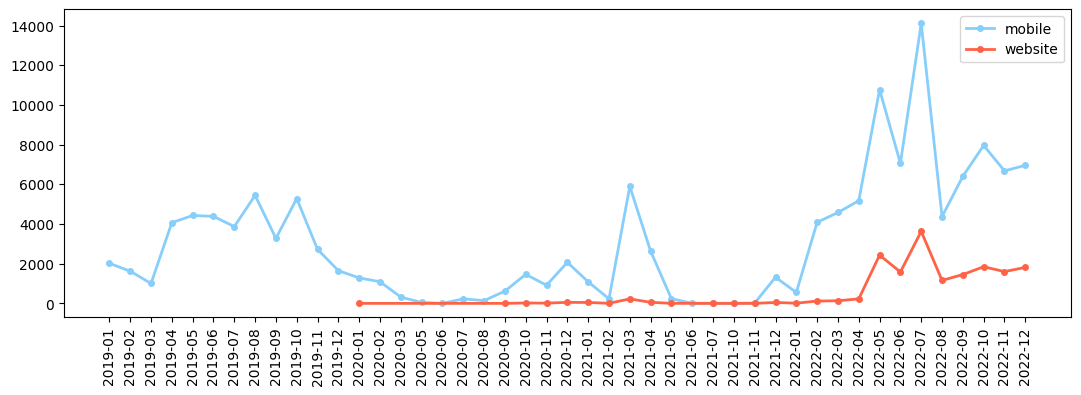

In [84]:
# Vẽ biểu đồ linechart:
plt.figure(figsize = (13,4))
df_mobile_line = df_platform_time[df_platform_time['platform']=='mobile']
plt.plot(df_mobile_line['year_month'],df_mobile_line['total_tickets'], label = 'mobile', marker = 'o', color ='lightskyblue', linewidth=2, markersize=4)

df_web_line = df_platform_time[df_platform_time['platform']=='website']
plt.plot(df_web_line['year_month'],df_web_line['total_tickets'], label = 'website', marker = 'o', color ='tomato', linewidth=2, markersize=4)
plt.legend()
plt.xticks(rotation=90)


**OS Version**


In [85]:
# phân loại thiết bị OS version thành các nhóm : android_others , IOS, unknown browser
df_join_all['os_version'] = df_join_all['model'].apply(lambda x: 'ios' if ('iPhone' in x or 'iPod' in x)
                                                      else 'browser' if x == 'browser'
                                                      else 'unknown' if ('devicemodel' in x or 'unknown' in x)
                                                      else 'android & other' )



In [86]:
df_join_all['os_version'].unique()

array(['ios', 'browser', 'unknown', 'android & other'], dtype=object)

In [87]:
# Group by để thống kê có bao nhiêu %
df_os =df_join_all.groupby('os_version').agg(total_tickets = ('ticket_id', 'count')).sort_values(by ='total_tickets', ascending = True).reset_index()


In [88]:
df_os

,os_version,total_tickets
0,browser,13377
1,android & other,21092
2,ios,51402
3,unknown,68854


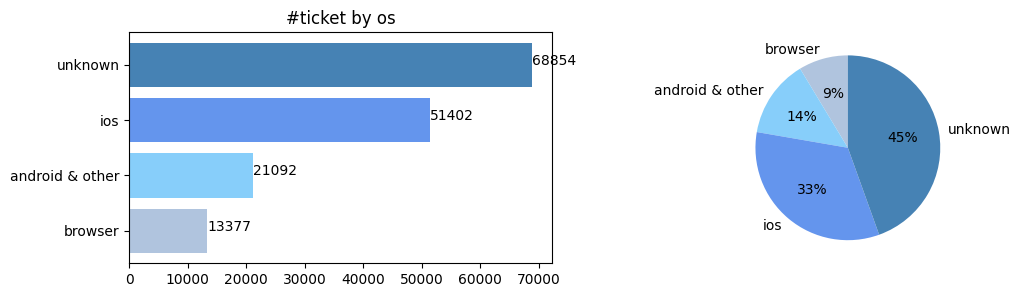

In [89]:
# Biểu đồ cột ngang :
plt.figure(figsize=(12, 3))

ax1 = plt.subplot(1,2,1)
plt.barh(
    df_os['os_version'], df_os['total_tickets'],
    color = df_os['os_version'].replace({ 'browser': 'lightsteelblue',  'android & other': 'lightskyblue', 'ios': 'cornflowerblue', 'unknown': 'steelblue'})
)

for index,value in enumerate(df_os['total_tickets']):
    plt.text(value,index,str(value))
plt.title('#ticket by os')

ax2 = plt.subplot(1,2,2)
plt.pie(df_os['total_tickets'], labels= df_os['os_version'],
        colors=df_os['os_version'].replace({ 'browser': 'lightsteelblue',  'android & other': 'lightskyblue', 'ios': 'cornflowerblue', 'unknown': 'steelblue'}),
        autopct='%1.0f%%',
        startangle=90)
plt.show()

In [90]:
# Theo thời gian
df_os_time=(
    df_join_all
    .groupby(['year_month','os_version'])
    .agg(total_tickets = ('ticket_id', 'count'))
    .sort_values(by ='year_month',ascending = True).reset_index()
)

In [91]:
df_os_time.head(10)

,year_month,os_version,total_tickets
0,2019-01,android & other,713
1,2019-01,ios,1233
2,2019-01,unknown,73
3,2019-02,android & other,542
4,2019-02,ios,1074
5,2019-02,unknown,10
6,2019-03,android & other,371
7,2019-03,ios,631
8,2019-03,unknown,2
9,2019-04,android & other,1519


In [92]:
# Xử lý data dạng PIVOT để vẽ biểu đồ miền:
df_os_time = (
    df_join_all
    .pivot_table(index ='year_month', columns = 'os_version', aggfunc = 'count', values = 'ticket_id').reset_index()
)

In [93]:
df_os_time.head(10)

os_version,year_month,android & other,browser,ios,unknown
0,2019-01,713.0,NaN,1233.0,73.0
1,2019-02,542.0,NaN,1074.0,10.0
2,2019-03,371.0,NaN,631.0,2.0
3,2019-04,1519.0,NaN,2541.0,9.0
4,2019-05,1601.0,NaN,2826.0,3.0
5,2019-06,1575.0,NaN,2808.0,4.0
6,2019-07,1373.0,NaN,2499.0,NaN
7,2019-08,1797.0,NaN,3642.0,5.0
8,2019-09,1122.0,NaN,2151.0,5.0
9,2019-10,1964.0,NaN,3313.0,7.0


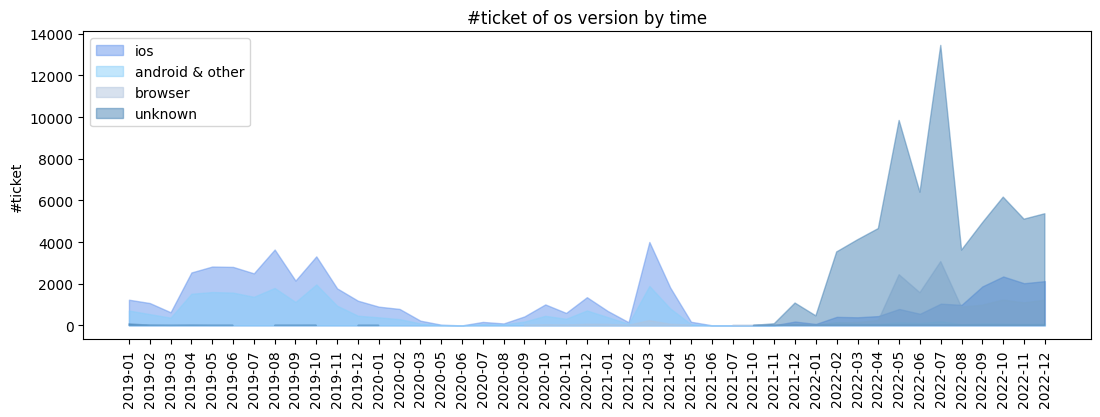

In [94]:
# Vẽ biểu đồ miền Thời gian
plt.figure(figsize = (13,4))
plt.fill_between(df_os_time['year_month'], df_os_time['ios'], color = 'cornflowerblue', alpha=0.5, label ='ios')
plt.fill_between(df_os_time['year_month'], df_os_time['android & other'], color = 'lightskyblue', alpha=0.5, label='android & other')
plt.fill_between(df_os_time['year_month'],df_os_time['browser'],color = 'lightsteelblue', alpha=0.5, label ='browser')
plt.fill_between(df_os_time['year_month'], df_os_time['unknown'], color = 'steelblue', alpha=0.5, label ='unknown')

# Hiển thị biểu đồ
plt.title('#ticket of os version by time')
#plt.xlabel('Month')
plt.ylabel('#ticket')
plt.legend(loc = 'upper left')
plt.xticks(rotation = 90)
plt.show()

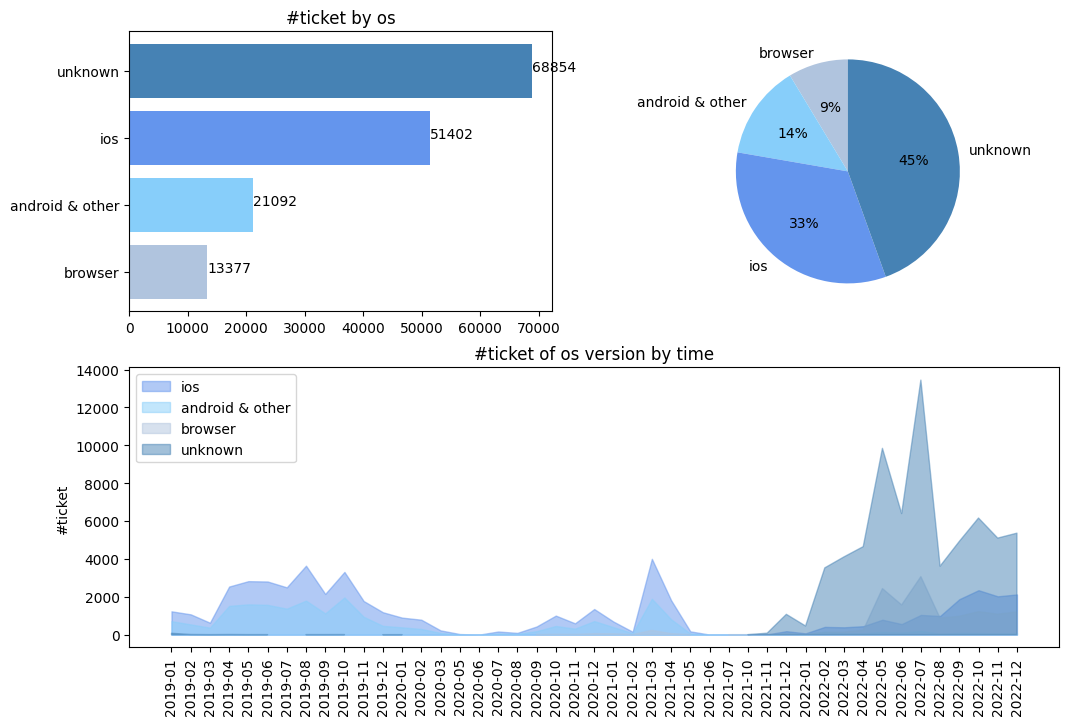

In [95]:
# Biểu đồ chung 1 frame:
plt.figure(figsize=(12,8))

ax1 = plt.subplot(2,2,1)
plt.barh(
    df_os['os_version'], df_os['total_tickets'],
    color = df_os['os_version'].replace({ 'browser': 'lightsteelblue',  'android & other': 'lightskyblue', 'ios': 'cornflowerblue', 'unknown': 'steelblue'})
)

for index,value in enumerate(df_os['total_tickets']):
    plt.text(value,index,str(value))
plt.title('#ticket by os')

ax2 = plt.subplot(2,2,2)
plt.pie(df_os['total_tickets'], labels= df_os['os_version'],
        colors=df_os['os_version'].replace({ 'browser': 'lightsteelblue',  'android & other': 'lightskyblue', 'ios': 'cornflowerblue', 'unknown': 'steelblue'}),
        autopct='%1.0f%%',
        startangle=90)


ax3 = plt.subplot(2,1,2)
plt.fill_between(df_os_time['year_month'], df_os_time['ios'], color = 'cornflowerblue', alpha=0.5, label ='ios')
plt.fill_between(df_os_time['year_month'], df_os_time['android & other'], color = 'lightskyblue', alpha=0.5, label='android & other')
plt.fill_between(df_os_time['year_month'],df_os_time['browser'],color = 'lightsteelblue', alpha=0.5, label ='browser')
plt.fill_between(df_os_time['year_month'], df_os_time['unknown'], color = 'steelblue', alpha=0.5, label ='unknown')

# Hiển thị biểu đồ
plt.title('#ticket of os version by time')
#plt.xlabel('Month')
plt.ylabel('#ticket')
plt.legend(loc = 'upper left')
plt.xticks(rotation = 90)
plt.show()

**Payment Method**

In [96]:
df_join_all.head(2)

,ticket_id,customer_id,paying_method,theater_name,device_number,original_price,discount_value,final_price,time,status_id,campaign_id,movie_name,usergender,dob,campaign_type,description,error_group,model,platform,age_days,age,month,name_day,hour,year_month,os_version
0,4f5200dcdcf2396b8d50ff84bf423f32,100009,money in app,13.0,244764a57dbdeb8fe9b164847ad55183,9.90,2.10,7.80,2022-07-08 17:46:36.145,1,83330,Thor: Love And Thunder,Male,1989-02-25,direct discount,Order successful,unknown,"iPhone13,1",mobile,13730,37,7,Friday,17,2022-07,ios
1,07abbaf28c772692f0367ad992bb3184,100493,bank account,180.0,8fa83cf46284aafd6e5da6c96f7862b5,8.66,1.48,7.18,2022-07-15 20:44:09.952,1,83330,Thor: Love And Thunder,Male,1991-06-09,direct discount,Order successful,unknown,browser,website,12896,35,7,Friday,20,2022-07,browser


In [97]:
df_method=(
     df_join_all[(df_join_all['status_id'] == 1) & (df_join_all['paying_method'] != 'other')]
    .groupby('paying_method')
    .agg(total_tickets = ('ticket_id', 'count'))
    .sort_values(by ='total_tickets',ascending = True).reset_index()
)

In [98]:
# Xử lý data dạng PIVOT để vẽ biểu đồ miền:
df_method_time = (
     df_join_all[(df_join_all['status_id'] == 1) & (df_join_all['paying_method'] != 'other')]
    .pivot_table(index ='year_month', columns = 'paying_method', aggfunc = 'count', values = 'ticket_id').reset_index()
)

In [99]:
df_method_time.head(10)

paying_method,year_month,bank account,credit card,debit card,money in app
0,2019-01,487.0,336.0,93.0,443.0
1,2019-02,484.0,370.0,93.0,480.0
2,2019-03,304.0,225.0,74.0,263.0
3,2019-04,1050.0,705.0,189.0,1246.0
4,2019-05,1092.0,903.0,212.0,1410.0
5,2019-06,1074.0,962.0,249.0,1319.0
6,2019-07,916.0,782.0,252.0,1215.0
7,2019-08,1367.0,1142.0,321.0,1684.0
8,2019-09,774.0,711.0,219.0,1068.0
9,2019-10,1280.0,914.0,309.0,1833.0


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44],
 [Text(0, 0, '2019-01'),
  Text(1, 0, '2019-02'),
  Text(2, 0, '2019-03'),
  Text(3, 0, '2019-04'),
  Text(4, 0, '2019-05'),
  Text(5, 0, '2019-06'),
  Text(6, 0, '2019-07'),
  Text(7, 0, '2019-08'),
  Text(8, 0, '2019-09'),
  Text(9, 0, '2019-10'),
  Text(10, 0, '2019-11'),
  Text(11, 0, '2019-12'),
  Text(12, 0, '2020-01'),
  Text(13, 0, '2020-02'),
  Text(14, 0, '2020-03'),
  Text(15, 0, '2020-05'),
  Text(16, 0, '2020-06'),
  Text(17, 0, '2020-07'),
  Text(18, 0, '2020-08'),
  Text(19, 0, '2020-09'),
  Text(20, 0, '2020-10'),
  Text(21, 0, '2020-11'),
  Text(22, 0, '2020-12'),
  Text(23, 0, '2021-01'),
  Text(24, 0, '2021-02'),
  Text(25, 0, '2021-03'),
  Text(26, 0, '2021-04'),
  Text(27, 0, '2021-05'),
  Text(28, 0, '2021-0

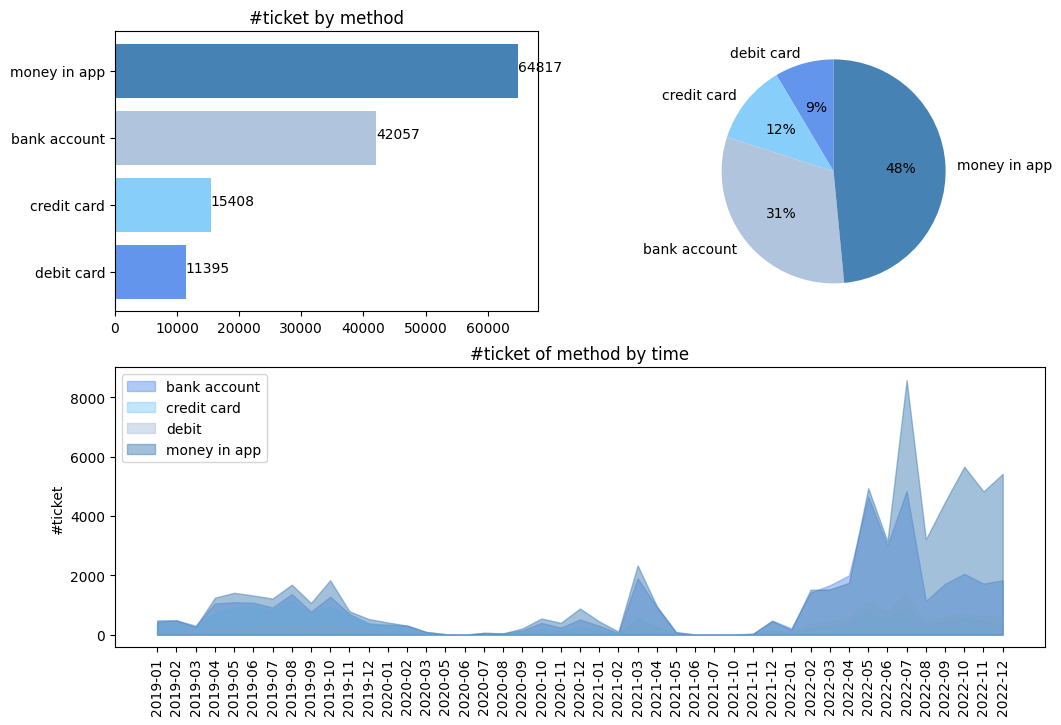

In [100]:
# biểu diễn chung 1 frame
plt.figure(figsize=(12, 8))

ax1 = plt.subplot(2,2,1)
plt.barh(
    df_method['paying_method'], df_method['total_tickets'],
    color = df_method['paying_method'].replace({ 'bank account': 'lightsteelblue',  'credit card': 'lightskyblue', 'debit card': 'cornflowerblue', 'money in app': 'steelblue'})
)

for index,value in enumerate(df_method['total_tickets']):
    plt.text(value,index,str(value))
plt.title('#ticket by method')

ax2 = plt.subplot(2,2,2)
plt.pie(df_method['total_tickets'], labels= df_method['paying_method'],
        colors=df_method['paying_method'].replace({ 'bank account': 'lightsteelblue',  'credit card': 'lightskyblue', 'debit card': 'cornflowerblue', 'money in app': 'steelblue'}),
        autopct='%1.0f%%',
        startangle=90)

ax3 = plt.subplot(2,1,2)
plt.fill_between(df_method_time['year_month'], df_method_time['bank account'], color='cornflowerblue', alpha=0.5, label='bank account')
plt.fill_between(df_method_time['year_month'], df_method_time['credit card'], color='lightskyblue', alpha=0.5, label='credit card')
plt.fill_between(df_method_time['year_month'], df_method_time['debit card'], color='lightsteelblue', alpha=0.5, label='debit')
plt.fill_between(df_method_time['year_month'], df_method_time['money in app'], color='steelblue', alpha=0.5, label='money in app')

plt.title('#ticket of method by time')
# plt.xlabel('Month')
plt.ylabel('#ticket')
plt.legend(loc='upper left')
plt.xticks(rotation=90)


In [101]:
# Biểu đồ miền 100%
df_method_time = (
     df_join_all[(df_join_all['status_id'] == 1) & (df_join_all['paying_method'] != 'other')]
    .pivot_table(index ='year_month', columns = 'paying_method', aggfunc = 'count', values = 'ticket_id').reset_index()
)
df_method_time_pct = df_method_time.copy()
df_method_time_pct = df_method_time_pct.fillna(0)
df_method_time_pct['total'] = df_method_time_pct.iloc[:, 1:].sum(axis=1)
for i in df_method_time_pct.columns[1:5]:
    df_method_time_pct[i+'_pct'] = df_method_time_pct[i]/df_method_time_pct['total']
df_method_time_pct.head(10)

paying_method,year_month,bank account,credit card,debit card,money in app,total,bank account_pct,credit card_pct,debit card_pct,money in app_pct
0,2019-01,487.0,336.0,93.0,443.0,1359.0,0.358352,0.247241,0.068433,0.325975
1,2019-02,484.0,370.0,93.0,480.0,1427.0,0.339173,0.259285,0.065172,0.336370
2,2019-03,304.0,225.0,74.0,263.0,866.0,0.351039,0.259815,0.085450,0.303695
3,2019-04,1050.0,705.0,189.0,1246.0,3190.0,0.329154,0.221003,0.059248,0.390596
4,2019-05,1092.0,903.0,212.0,1410.0,3617.0,0.301908,0.249654,0.058612,0.389826
5,2019-06,1074.0,962.0,249.0,1319.0,3604.0,0.298002,0.266926,0.069090,0.365982
6,2019-07,916.0,782.0,252.0,1215.0,3165.0,0.289415,0.247077,0.079621,0.383886
7,2019-08,1367.0,1142.0,321.0,1684.0,4514.0,0.302836,0.252991,0.071112,0.373062
8,2019-09,774.0,711.0,219.0,1068.0,2772.0,0.279221,0.256494,0.079004,0.385281
9,2019-10,1280.0,914.0,309.0,1833.0,4336.0,0.295203,0.210793,0.071264,0.422740


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44],
 [Text(0, 0, '2019-01'),
  Text(1, 0, '2019-02'),
  Text(2, 0, '2019-03'),
  Text(3, 0, '2019-04'),
  Text(4, 0, '2019-05'),
  Text(5, 0, '2019-06'),
  Text(6, 0, '2019-07'),
  Text(7, 0, '2019-08'),
  Text(8, 0, '2019-09'),
  Text(9, 0, '2019-10'),
  Text(10, 0, '2019-11'),
  Text(11, 0, '2019-12'),
  Text(12, 0, '2020-01'),
  Text(13, 0, '2020-02'),
  Text(14, 0, '2020-03'),
  Text(15, 0, '2020-05'),
  Text(16, 0, '2020-06'),
  Text(17, 0, '2020-07'),
  Text(18, 0, '2020-08'),
  Text(19, 0, '2020-09'),
  Text(20, 0, '2020-10'),
  Text(21, 0, '2020-11'),
  Text(22, 0, '2020-12'),
  Text(23, 0, '2021-01'),
  Text(24, 0, '2021-02'),
  Text(25, 0, '2021-03'),
  Text(26, 0, '2021-04'),
  Text(27, 0, '2021-05'),
  Text(28, 0, '2021-0

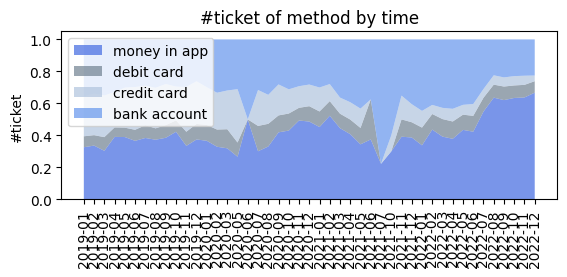

In [102]:
ax3 = plt.subplot(2,1,2)
plt.stackplot(df_method_time_pct['year_month'], df_method_time_pct["money in app_pct"],  df_method_time_pct['debit card_pct'], df_method_time_pct['credit card_pct'], df_method_time_pct['bank account_pct']
              , labels=['money in app', 'debit card', 'credit card', 'bank account'], colors=['royalblue', 'slategrey', 'lightsteelblue', 'cornflowerblue'], alpha=0.7)

plt.title('#ticket of method by time')
# plt.xlabel('Month')
plt.ylabel('#ticket')
plt.legend(loc='upper left')
plt.xticks(rotation=90)


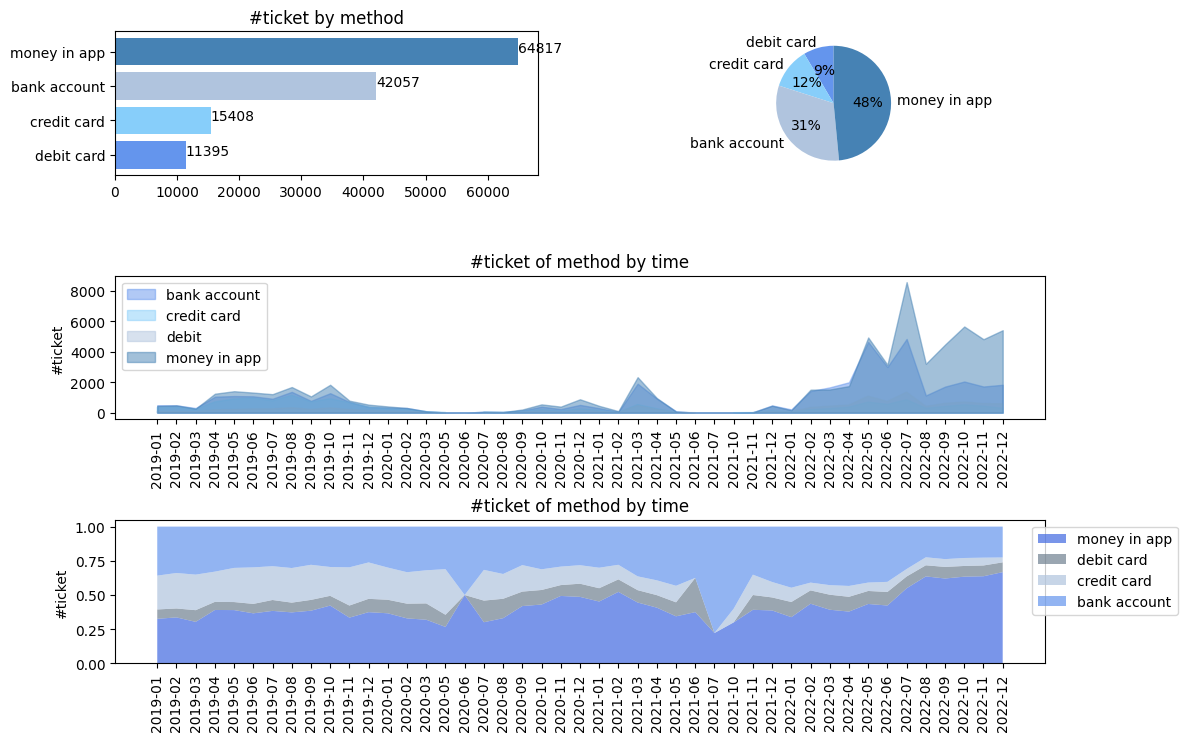

In [103]:
# Biểu đồ chung 1 frame:
plt.figure(figsize=(12, 8))

ax1 = plt.subplot(3,2,1)
plt.barh(
    df_method['paying_method'], df_method['total_tickets'],
    color = df_method['paying_method'].replace({ 'bank account': 'lightsteelblue',  'credit card': 'lightskyblue', 'debit card': 'cornflowerblue', 'money in app': 'steelblue'})
)

for index,value in enumerate(df_method['total_tickets']):
    plt.text(value,index,str(value))
plt.title('#ticket by method')

ax2 = plt.subplot(3,2,2)
plt.pie(df_method['total_tickets'], labels= df_method['paying_method'],
        colors=df_method['paying_method'].replace({ 'bank account': 'lightsteelblue',  'credit card': 'lightskyblue', 'debit card': 'cornflowerblue', 'money in app': 'steelblue'}),
        autopct='%1.0f%%',
        startangle=90)

ax3 = plt.subplot(3,1,2)
plt.fill_between(df_method_time['year_month'], df_method_time['bank account'], color='cornflowerblue', alpha=0.5, label='bank account')
plt.fill_between(df_method_time['year_month'], df_method_time['credit card'], color='lightskyblue', alpha=0.5, label='credit card')
plt.fill_between(df_method_time['year_month'], df_method_time['debit card'], color='lightsteelblue', alpha=0.5, label='debit')
plt.fill_between(df_method_time['year_month'], df_method_time['money in app'], color='steelblue', alpha=0.5, label='money in app')

plt.title('#ticket of method by time')
# plt.xlabel('Month')
plt.ylabel('#ticket')
plt.legend(loc='upper left')
plt.xticks(rotation=90)


ax4 = plt.subplot(3,1,3)
#Biểu đồ miền 100%
plt.stackplot(df_method_time_pct['year_month'], df_method_time_pct["money in app_pct"],  df_method_time_pct['debit card_pct'], df_method_time_pct['credit card_pct'], df_method_time_pct['bank account_pct']
              , labels=['money in app', 'debit card', 'credit card', 'bank account'], colors=['royalblue', 'slategrey', 'lightsteelblue', 'cornflowerblue'], alpha=0.7)

plt.title('#ticket of method by time')
# plt.xlabel('Month')
plt.ylabel('#ticket')
plt.legend(loc='upper right', bbox_to_anchor=(1.15,1))
plt.xticks(rotation=90)

plt.subplots_adjust(hspace = 0.7, top = 0.9)

**Promotion**


In [104]:
df_join_all['campaign_type'].unique()

array(['direct discount', 'unknown', 'voucher', 'reward point'],
      dtype=object)

In [105]:
df_join_all['type'] = df_join_all['campaign_type'].apply(lambda x: 'non-promotion' if x == 'unknown' else 'promotion')

In [106]:
df_join_all.head(2)

,ticket_id,customer_id,paying_method,theater_name,device_number,original_price,discount_value,final_price,time,status_id,campaign_id,movie_name,usergender,dob,campaign_type,description,error_group,model,platform,age_days,age,month,name_day,hour,year_month,os_version,type
0,4f5200dcdcf2396b8d50ff84bf423f32,100009,money in app,13.0,244764a57dbdeb8fe9b164847ad55183,9.90,2.10,7.80,2022-07-08 17:46:36.145,1,83330,Thor: Love And Thunder,Male,1989-02-25,direct discount,Order successful,unknown,"iPhone13,1",mobile,13730,37,7,Friday,17,2022-07,ios,promotion
1,07abbaf28c772692f0367ad992bb3184,100493,bank account,180.0,8fa83cf46284aafd6e5da6c96f7862b5,8.66,1.48,7.18,2022-07-15 20:44:09.952,1,83330,Thor: Love And Thunder,Male,1991-06-09,direct discount,Order successful,unknown,browser,website,12896,35,7,Friday,20,2022-07,browser,promotion


In [107]:
df_type = (
    df_join_all[(df_join_all['status_id']== 1) & (df_join_all['paying_method'] != 'other')]
    .groupby('type')
    .agg(total_tickets = ('ticket_id', 'count'))
    .sort_values(by = 'total_tickets', ascending = True).reset_index()
)

In [108]:
df_type

,type,total_tickets
0,non-promotion,55155
1,promotion,78522


In [109]:
# Xử lý data dạng PIVOT để vẽ biểu đồ miền :
df_type_time=(
    df_join_all[(df_join_all['status_id']==1) & (df_join_all['paying_method']!= 'other')]
    .pivot_table(index = 'year_month', columns = 'type', aggfunc = 'count', values= 'ticket_id')
    .reset_index()
)

In [110]:
# Biểu đồ miền 100%
df_type_time = (
    df_join_all[(df_join_all['status_id'] ==1) & (df_join_all['paying_method'] != 'other')]
    .pivot_table(index = 'year_month', columns = 'type', aggfunc = 'count', values = 'ticket_id')
    .reset_index()
)

df_type_time_pct = df_type_time.copy()

df_type_time_pct = df_type_time_pct.fillna(0)

df_type_time_pct['total'] = df_type_time_pct.iloc[:, 1:].sum(axis =1)

for i in df_type_time_pct.columns[1:3]:
    df_type_time_pct[i +'_pct'] = df_type_time_pct[i]/df_type_time_pct['total']

In [111]:
df_type_time_pct.head(5)

type,year_month,non-promotion,promotion,total,non-promotion_pct,promotion_pct
0,2019-01,517.0,842.0,1359.0,0.380427,0.619573
1,2019-02,1335.0,92.0,1427.0,0.935529,0.064471
2,2019-03,835.0,31.0,866.0,0.964203,0.035797
3,2019-04,1699.0,1491.0,3190.0,0.532602,0.467398
4,2019-05,1564.0,2053.0,3617.0,0.432403,0.567597


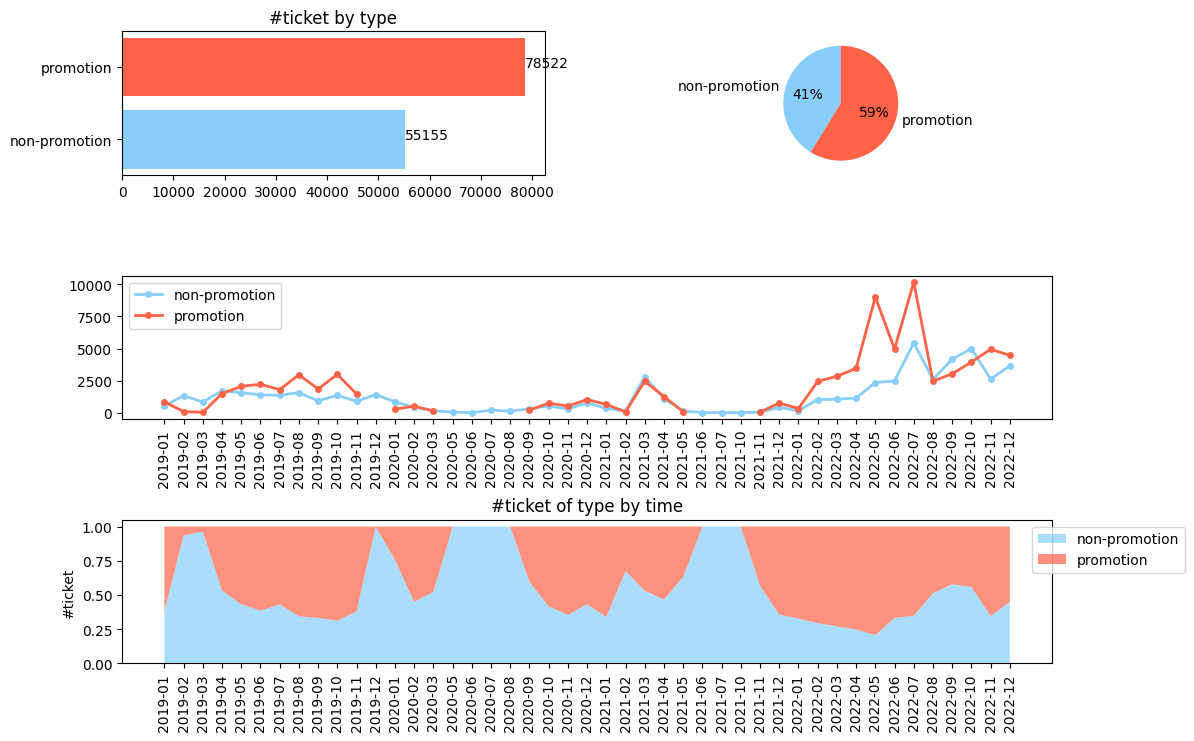

In [112]:
# Biểu đồ chung 1 frame:
plt.figure(figsize=(12, 8))

ax1 = plt.subplot(3,2,1)
plt.barh(
    df_type['type'], df_type['total_tickets'],
    color = df_type['type'].replace({ 'non-promotion': 'lightskyblue',  'promotion': 'tomato'})
)

for index,value in enumerate(df_type['total_tickets']):
    plt.text(value,index,str(value))
plt.title('#ticket by type')

ax2 = plt.subplot(3,2,2)
plt.pie(df_type['total_tickets'], labels= df_type['type'],
        colors=df_type['type'].replace({ 'non-promotion': 'lightskyblue',  'promotion': 'tomato'}),
        autopct='%1.0f%%',
        startangle=90)

ax3 = plt.subplot(3,1,2)

plt.plot(df_type_time['year_month'],df_type_time['non-promotion'], label = 'non-promotion', marker = 'o', color ='lightskyblue', linewidth=2, markersize=4)

plt.plot(df_type_time['year_month'],df_type_time['promotion'], label = 'promotion', marker = 'o', color ='tomato', linewidth=2, markersize=4)
plt.legend()
plt.xticks(rotation=90)



ax4 = plt.subplot(3,1,3)
#Biểu đồ miền 100%
plt.stackplot(df_type_time_pct['year_month'], df_type_time_pct['non-promotion_pct'],  df_type_time_pct['promotion_pct']
              , labels=['non-promotion', 'promotion'], colors=['lightskyblue', 'tomato'], alpha=0.7)

plt.title('#ticket of type by time')
# plt.xlabel('Month')
plt.ylabel('#ticket')
plt.legend(loc='upper right', bbox_to_anchor=(1.15,1))
plt.xticks(rotation=90)

plt.subplots_adjust(hspace = 0.7, top = 0.9)

**Which movies they watched ?**

In [113]:
df_film_sum =(
    df_join_all[df_join_all['status_id']==1]
    .groupby('movie_name')
    .agg(total_tickets = ('ticket_id', 'count'),
         total_customers = ('customer_id', 'nunique'),
         revenue = ('final_price', 'sum'))
    .sort_values(by = 'total_tickets', ascending = False).reset_index()
)

In [114]:
df_film_sum.head(30)

,movie_name,total_tickets,total_customers,revenue
0,Doctor Strange In The Multiverse Of Madness,8615,8409,65579.98
1,Minions: The Rise Of Gru,7224,7014,56530.93
2,Avatar: The Way Of Water,5870,5612,59830.95
3,Thor: Love And Thunder,5589,5478,43372.90
4,Peninsula,5499,5365,41208.44
5,Black Panther 2: Wakanda Forever,3847,3790,26860.28
6,Black Adam,3229,3186,23159.34
7,Avengers: Endgame,3219,3135,26690.48
8,Dad I'm Sorry,3023,2817,25863.28
9,Love Destiny,2411,2376,18345.61


In [115]:
list_film = df_film_sum[df_film_sum['total_tickets'] > 1000]['movie_name'].unique()
list_selected_film = list(list_film)

In [116]:
list_selected_film

['Doctor Strange In The Multiverse Of Madness',
 'Minions: The Rise Of Gru',
 'Avatar: The Way Of Water',
 'Thor: Love And Thunder',
 'Peninsula',
 'Black Panther 2: Wakanda Forever',
 'Black Adam',
 'Avengers: Endgame',
 "Dad I'm Sorry",
 'Love Destiny',
 'You And Trinh',
 'Fast & Furious Presents: Hobbs & Shaw',
 'Emergency Declaration',
 'Jurassic World Dominion',
 'Godzilla Vs. Kong',
 'Detective Conan: The Bride Of Halloween',
 'Joker',
 'Spider-Man: No Way Home',
 'Batman',
 'Blood Moon Party',
 'Fantastic Beasts: Secrets Of Dumbledore',
 'Top Gun: Maverick',
 'Naked Truth',
 "Doraemon: Nobita's Little Star Wars 2021",
 'One Piece Film: Red',
 'Confidential Assignment 2: International',
 'Extremely Easy Job',
 'Morbius',
 'Spider-Man Far From Home',
 'Maleficent',
 'Face Off: 48h',
 'Parasite']

In [117]:
# Xử lý data dạng PIVOT để vẽ biểu đồ miền :
df_movie_time_pivot=(
    df_join_all[(df_join_all['status_id']==1) & (df_join_all['movie_name'].isin(list_selected_film))]
    .pivot_table(index = 'year_month', columns = 'movie_name', aggfunc = 'count', values= 'ticket_id')
    .reset_index()
)

In [118]:
df_movie_time_pivot.head(20)

movie_name,year_month,Avatar: The Way Of Water,Avengers: Endgame,Batman,Black Adam,Black Panther 2: Wakanda Forever,Blood Moon Party,Confidential Assignment 2: International,Dad I'm Sorry,Detective Conan: The Bride Of Halloween,Doctor Strange In The Multiverse Of Madness,Doraemon: Nobita's Little Star Wars 2021,Emergency Declaration,Extremely Easy Job,Face Off: 48h,Fantastic Beasts: Secrets Of Dumbledore,Fast & Furious Presents: Hobbs & Shaw,Godzilla Vs. Kong,Joker,Jurassic World Dominion,Love Destiny,Maleficent,Minions: The Rise Of Gru,Morbius,Naked Truth,One Piece Film: Red,Parasite,Peninsula,Spider-Man Far From Home,Spider-Man: No Way Home,Thor: Love And Thunder,Top Gun: Maverick,You And Trinh
0,2019-04,NaN,2081.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-05,NaN,1130.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2019-06,NaN,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,751.0,NaN,28.0,NaN,NaN,NaN,NaN
3,2019-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,126.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,286.0,NaN,1125.0,NaN,NaN,NaN,NaN
4,2019-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1950.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2019-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.0,NaN,34.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2019-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1405.0,NaN,NaN,1008.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2019-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,79.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2020-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.0,NaN,NaN,NaN,NaN,NaN,NaN
9,2020-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN


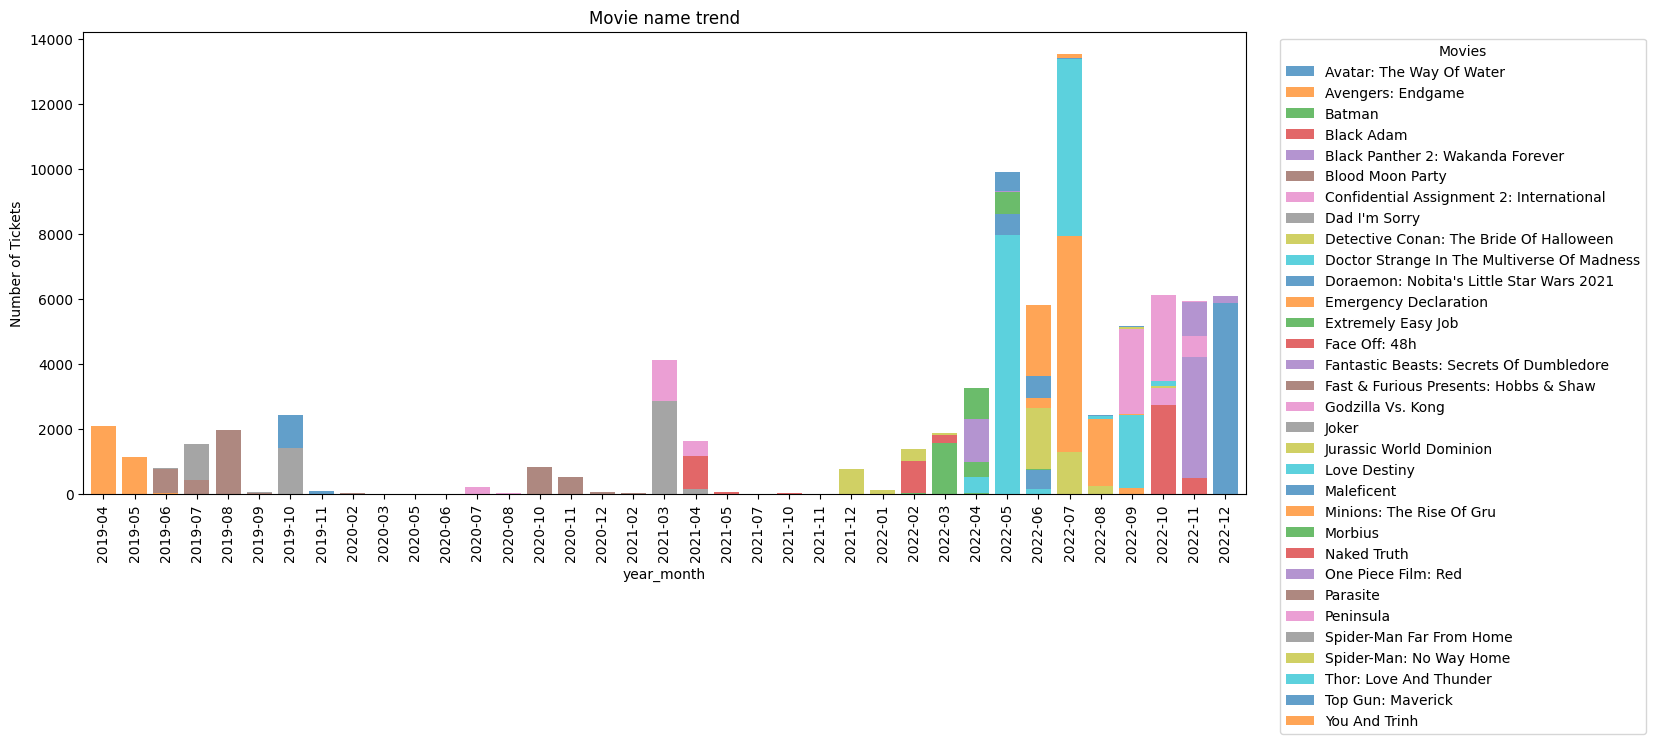

In [119]:
# Biểu đồ bar cột chồng lên nhau :
#Biểu đồ cột chồng
ax = df_movie_time_pivot.plot(x = 'year_month', kind='bar', stacked=True, figsize=(15, 6), width=0.8, alpha = 0.7)

# Set the title and labels
ax.set_title('Movie name trend')
# ax.set_xlabel('Month')
ax.set_ylabel('Number of Tickets')

# Add a legend
plt.legend(title='Movies', loc='upper right', bbox_to_anchor=(1.35, 1))

# Show the plot
plt.show()

**3.4 Customer value dimension**



*  Mục tiêu: Phân tích các chỉ số về giá trị mà 1 khách hàng mang lại
     *   Frequency: count, day, month
     *   Monetary: total_money, total_discount
     *   Success rate = number_success/total
     *   Promotion_rate = number_promotion/total_success
     *   Discount_rate = sum_discount/sum_money











In [120]:
df_join_all.head(2)

,ticket_id,customer_id,paying_method,theater_name,device_number,original_price,discount_value,final_price,time,status_id,campaign_id,movie_name,usergender,dob,campaign_type,description,error_group,model,platform,age_days,age,month,name_day,hour,year_month,os_version,type
0,4f5200dcdcf2396b8d50ff84bf423f32,100009,money in app,13.0,244764a57dbdeb8fe9b164847ad55183,9.90,2.10,7.80,2022-07-08 17:46:36.145,1,83330,Thor: Love And Thunder,Male,1989-02-25,direct discount,Order successful,unknown,"iPhone13,1",mobile,13730,37,7,Friday,17,2022-07,ios,promotion
1,07abbaf28c772692f0367ad992bb3184,100493,bank account,180.0,8fa83cf46284aafd6e5da6c96f7862b5,8.66,1.48,7.18,2022-07-15 20:44:09.952,1,83330,Thor: Love And Thunder,Male,1991-06-09,direct discount,Order successful,unknown,browser,website,12896,35,7,Friday,20,2022-07,browser,promotion


In [121]:
# Tính tất cả các chỉ số trên:
# Tính các chỉ số cho những vé thanh toán thành công
def calculate_n_promotion(x):
  return(x == 'promotion').sum()

df_success_metric = (
    df_join_all[df_join_all['status_id'] ==1]
    .assign(date = pd.to_datetime(df_join_all['time']).dt.date)
    .groupby('customer_id')
    .agg(
        n_success = ('ticket_id', 'count'),
        s_money = ('original_price', 'sum'),
        s_discount = ('discount_value', 'sum'),
        n_day = ('date', 'nunique'),
        n_months = ('year_month','nunique'),
        n_promotion = ('type', calculate_n_promotion)
    )
    .reset_index()
)

In [122]:
# Tính các chỉ số: total và giao dịch lối:
def calculate_n_failed(x):
  return(x != 1).sum() # biến status_id !=1


df_failed_metric = (
    df_join_all
    .groupby('customer_id')
    .agg(
        n_total = ('ticket_id', 'count'),
       n_failed  = ('status_id',calculate_n_failed )
    )
    .reset_index()
)

In [123]:
df_success_metric.head(2)

,customer_id,n_success,s_money,s_discount,n_day,n_months,n_promotion
0,100001,1,7.42,2.06,1,1,1
1,100003,6,60.95,2.56,6,6,1


In [124]:
df_failed_metric.head(2)

,customer_id,n_total,n_failed
0,100001,1,0
1,100003,6,0


In [125]:
# Join 2 bảng này lại:
df_customer_value = (
    pd.merge(df_failed_metric, df_success_metric, how = 'left', on = 'customer_id').fillna(0)
)

In [126]:
df_customer_value.head(5)

,customer_id,n_total,n_failed,n_success,s_money,s_discount,n_day,n_months,n_promotion
0,100001,1,0,1.0,7.42,2.06,1.0,1.0,1.0
1,100003,6,0,6.0,60.95,2.56,6.0,6.0,1.0
2,100004,1,0,1.0,32.25,0.00,1.0,1.0,0.0
3,100005,1,0,1.0,9.49,2.06,1.0,1.0,1.0
4,100006,1,0,1.0,12.37,0.00,1.0,1.0,0.0


In [127]:
df_customer_value['success_rate'] = df_customer_value['n_success']/df_customer_value['n_total']
df_customer_value['promotion_rate'] = df_customer_value['n_promotion']/df_customer_value['n_success']
df_customer_value['discount_rate'] = df_customer_value['s_discount']/df_customer_value['s_money']

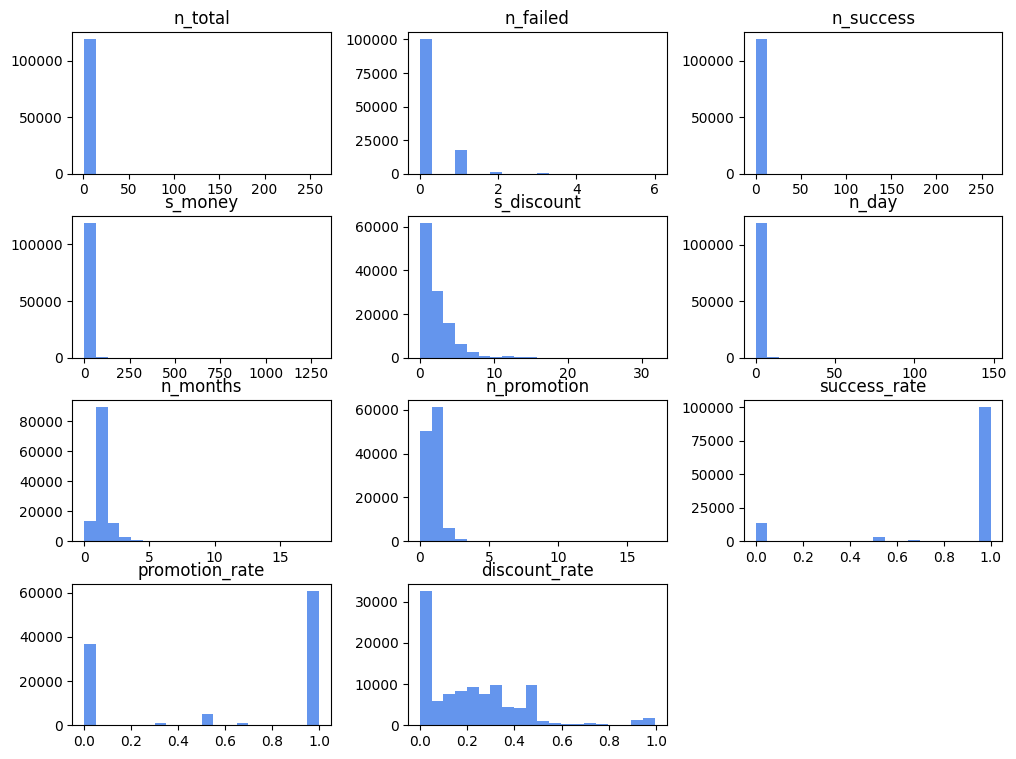

In [128]:
# Visualize tất cả các chỉ số bằng histogram:
df_customer_value.iloc[:, 1:].hist(figsize = (12,9), grid = False, color = 'cornflowerblue', bins =20)
plt.show()

**Note**
 * **n_total**: hầu hết KH mua vé rất ít (1-2 vé) nhưng có top những người mua
rất nhiều -> check những người này.
 * **n_success_rate**: có khoảng  ~ 10% giao dịch Success_rate = 0 -> Kiểm tra lỗi gì ?
 * **n_promotion_rate**: có hơn 60.000 KH chỉ tham gia promotion khi mà rate 100%
* **n_promotion** : 60.000 KH chỉ hưởng promotion 1 lần(có liên quan gì đến nhóm ở promotion_rate =100% hay không?)

**Frequency & anomaly behavior**

In [129]:
df_customer_value['n_order_dis'] = df_customer_value['n_success'].apply(lambda x :'more than 10' if x >= 10 else str(x))

In [130]:
df_customer_value.head(2)

,customer_id,n_total,n_failed,n_success,s_money,s_discount,n_day,n_months,n_promotion,success_rate,promotion_rate,discount_rate,n_order_dis
0,100001,1,0,1.0,7.42,2.06,1.0,1.0,1.0,1.0,1.000000,0.277628,1.0
1,100003,6,0,6.0,60.95,2.56,6.0,6.0,1.0,1.0,0.166667,0.042002,6.0


In [131]:
df_n_dis = df_customer_value.groupby('n_order_dis').agg(total_cus = ('customer_id', 'count')).reset_index()

In [132]:
df_n_dis.head(12)

,n_order_dis,total_cus
0,0.0,13701
1,1.0,87921
2,2.0,12902
3,3.0,3145
4,4.0,1017
5,5.0,380
6,6.0,168
7,7.0,92
8,8.0,47
9,9.0,30


Text(0.5, 1.0, '#customer of each group')

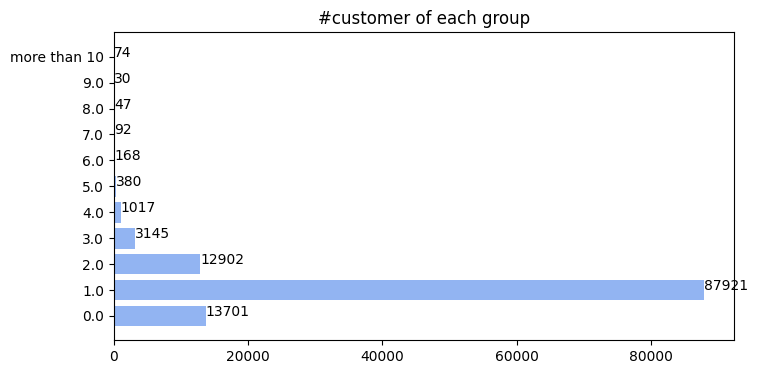

In [133]:
# Biểu đồ cột ngang
plt.figure(figsize = (8,4))

plt.barh(
    df_n_dis['n_order_dis'],df_n_dis['total_cus']
    ,color = 'cornflowerblue'
    , alpha = 0.7
)
for index,value in enumerate(df_n_dis['total_cus']):
  plt.text(value, index, str(value))

plt.title('#customer of each group')


In [134]:
df_customer_value.count()

,0
customer_id,119477
n_total,119477
n_failed,119477
n_success,119477
s_money,119477
s_discount,119477
n_day,119477
n_months,119477
n_promotion,119477
success_rate,119477


In [135]:
# Nếu họ mua dồn vào 1 lúc ->  bất thường
# Nếu mua dàn trải : -> bình thường

In [136]:
df_customer_value.sort_values(by = 'n_success', ascending = False).head(20)

,customer_id,n_total,n_failed,n_success,s_money,s_discount,n_day,n_months,n_promotion,success_rate,promotion_rate,discount_rate,n_order_dis
2686,102948,260,0,260.0,1291.25,3.38,148.0,18.0,1.0,1.000000,0.003846,0.002618,more than 10
48948,153588,108,1,107.0,434.59,0.00,77.0,14.0,0.0,0.990741,0.000000,0.000000,more than 10
10604,111644,104,0,104.0,581.70,18.52,85.0,18.0,9.0,1.000000,0.086538,0.031838,more than 10
15783,117362,104,1,103.0,744.86,8.62,79.0,15.0,6.0,0.990385,0.058252,0.011573,more than 10
16687,118349,83,3,80.0,344.56,4.21,62.0,17.0,1.0,0.963855,0.012500,0.012218,more than 10
20907,122962,77,1,76.0,447.00,1.86,45.0,9.0,3.0,0.987013,0.039474,0.004161,more than 10
72718,179471,69,1,68.0,375.91,7.14,51.0,9.0,4.0,0.985507,0.058824,0.018994,more than 10
62432,168132,69,3,66.0,249.03,0.00,59.0,14.0,0.0,0.956522,0.000000,0.000000,more than 10
111563,222641,51,0,51.0,240.84,2.31,41.0,11.0,3.0,1.000000,0.058824,0.009591,more than 10
53097,158089,53,2,51.0,245.14,1.69,40.0,14.0,2.0,0.962264,0.039216,0.006894,more than 10


In [137]:
list_customer_massive = list(df_customer_value[df_customer_value['n_success'] > 30]['customer_id'].unique())

In [138]:
list_customer_massive

[np.int64(102948),
 np.int64(103035),
 np.int64(103347),
 np.int64(108110),
 np.int64(108162),
 np.int64(108729),
 np.int64(111644),
 np.int64(114205),
 np.int64(117140),
 np.int64(117362),
 np.int64(117475),
 np.int64(118349),
 np.int64(122962),
 np.int64(131905),
 np.int64(153124),
 np.int64(153588),
 np.int64(158089),
 np.int64(168132),
 np.int64(179471),
 np.int64(222641),
 np.int64(226527),
 np.int64(226886)]

In [139]:
df_customer_massive_pivot = (
    df_join_all[(df_join_all['customer_id'].isin(list_customer_massive)) & (df_join_all['status_id']==1)]
    .pivot_table(index = 'year_month', columns = 'customer_id', aggfunc = 'count', values = 'ticket_id')
    .reset_index()
)

In [140]:
df_customer_massive_pivot.head(20)

customer_id,year_month,102948,103035,103347,108110,108162,108729,111644,114205,117140,117362,117475,118349,122962,131905,153124,153588,158089,168132,179471,222641,226527,226886
0,2019-01,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-02,NaN,NaN,NaN,NaN,1.0,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2019-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2019-04,NaN,3.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,2.0,NaN,3.0,NaN,NaN,NaN,NaN,NaN
4,2019-05,NaN,2.0,NaN,NaN,4.0,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,2.0,3.0,NaN,7.0,NaN,NaN,NaN,NaN,NaN
5,2019-06,NaN,NaN,NaN,NaN,2.0,NaN,NaN,2.0,1.0,NaN,1.0,NaN,NaN,1.0,7.0,NaN,2.0,NaN,NaN,NaN,NaN,NaN
6,2019-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,3.0,NaN,NaN,NaN,NaN,NaN
7,2019-08,NaN,3.0,NaN,NaN,NaN,NaN,NaN,6.0,NaN,NaN,NaN,NaN,NaN,1.0,7.0,NaN,5.0,NaN,NaN,NaN,NaN,NaN
8,2019-09,NaN,2.0,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,2.0,1.0,NaN,2.0,NaN,NaN,NaN,NaN,NaN
9,2019-10,NaN,4.0,NaN,NaN,NaN,NaN,1.0,3.0,NaN,NaN,NaN,NaN,NaN,1.0,1.0,NaN,7.0,NaN,NaN,NaN,NaN,NaN


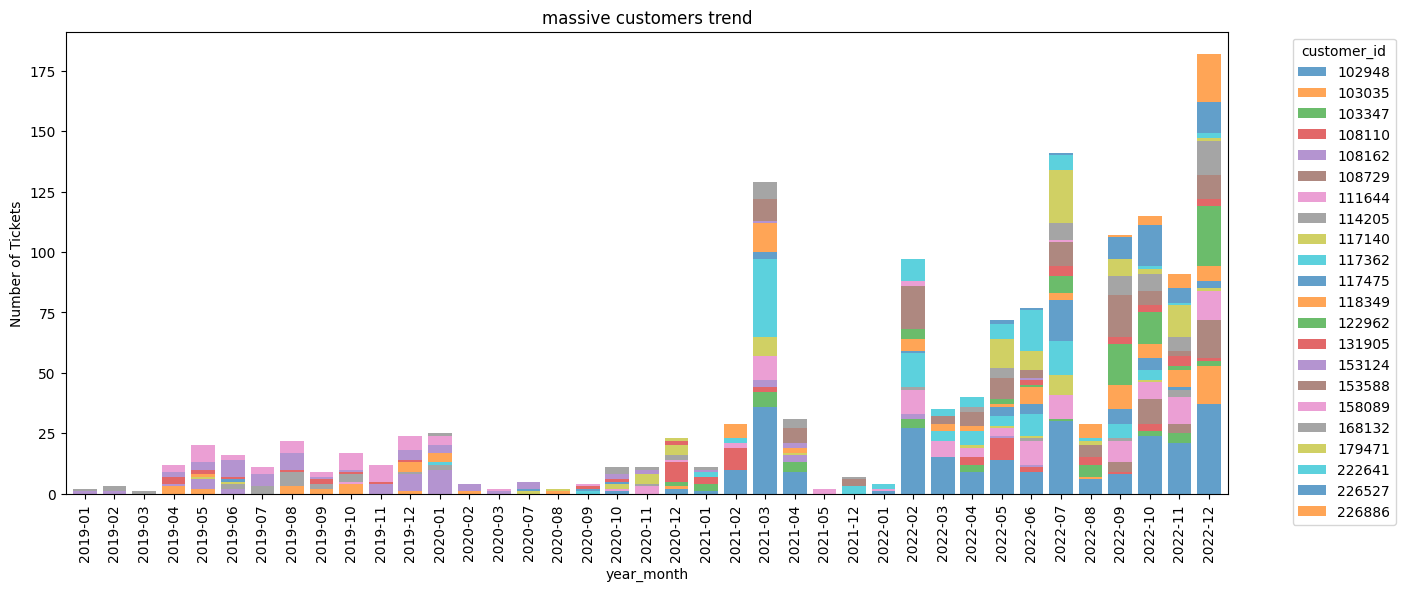

In [141]:
# Biểu đồ cột chồng lên nhau:
ax = df_customer_massive_pivot.plot(x = 'year_month', kind = 'bar', stacked = True, figsize = (15,6), width = 0.8, alpha = 0.7)

# Set the title and labels
ax.set_title('massive customers trend')
# ax.set_xlabel('Month')
ax.set_ylabel('Number of Tickets')

# Add a legend
plt.legend(title = 'customer_id', loc = 'upper right', bbox_to_anchor=(1.15, 1))

# Show the plot
plt.show()

>**Notes:**
*  -Nhóm KH mau vé > 30 lượt phân bổ dàn trải --> không có hiện tượng spam vé,
mua đi bán lại
*  -Chưa có gì bất thường.

**Masive promotion**

In [142]:
df_customer_value['n_promo_dis'] =df_customer_value['n_promotion'].apply(lambda x :'more than 10' if x >= 10 else str(x))

In [143]:
df_customer_value.head(2)

,customer_id,n_total,n_failed,n_success,s_money,s_discount,n_day,n_months,n_promotion,success_rate,promotion_rate,discount_rate,n_order_dis,n_promo_dis
0,100001,1,0,1.0,7.42,2.06,1.0,1.0,1.0,1.0,1.000000,0.277628,1.0,1.0
1,100003,6,0,6.0,60.95,2.56,6.0,6.0,1.0,1.0,0.166667,0.042002,6.0,1.0


In [144]:
df_promo_dis = df_customer_value.groupby('n_promo_dis').agg(total_cus = ('customer_id', 'count')).reset_index()

In [145]:
df_promo_dis.head(11)

,n_promo_dis,total_cus
0,0.0,50498
1,1.0,61334
2,2.0,6264
3,3.0,1042
4,4.0,230
5,5.0,74
6,6.0,19
7,7.0,10
8,8.0,2
9,9.0,2


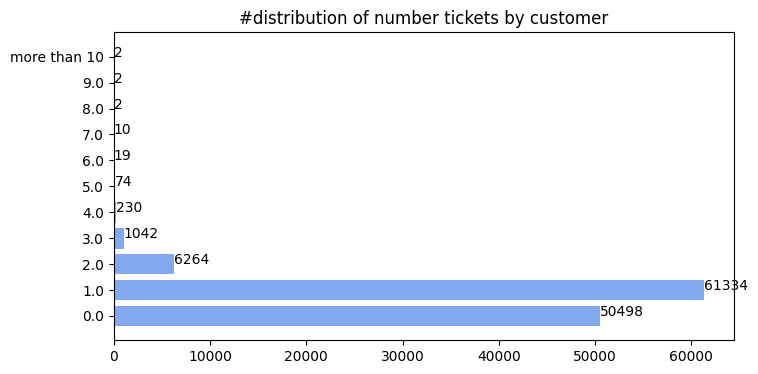

In [146]:
# Biểu đồ cột ngang:
plt.figure(figsize =(8,4))

plt.barh(
    df_promo_dis['n_promo_dis'], df_promo_dis['total_cus'],
    color = 'cornflowerblue',
    alpha = 0.8
)

for index, value in enumerate(df_promo_dis['total_cus']):
  plt.text(value, index, str(value))

plt.title('#distribution of number tickets by customer')
plt.show()

>> -  ~ 60% KH là join các chương trình khuyến mãi
>> - Trong đó 90% chỉ hưởng khuyến mãi 1 lần duy nhất
>>> - 1. Khách hàng đến 1 lần rồi thôi
>>> - 2. Các chương trình promotion chỉ cho 1 người dùng 1 lần(dành cho new customers) ?  --> verify với team product hoặc MKT

In [147]:
### Vậy loại KM mà KH đang dùng là gì ?

In [148]:
70/120

0.5833333333333334

In [149]:
df_join_all.head(2)

,ticket_id,customer_id,paying_method,theater_name,device_number,original_price,discount_value,final_price,time,status_id,campaign_id,movie_name,usergender,dob,campaign_type,description,error_group,model,platform,age_days,age,month,name_day,hour,year_month,os_version,type
0,4f5200dcdcf2396b8d50ff84bf423f32,100009,money in app,13.0,244764a57dbdeb8fe9b164847ad55183,9.90,2.10,7.80,2022-07-08 17:46:36.145,1,83330,Thor: Love And Thunder,Male,1989-02-25,direct discount,Order successful,unknown,"iPhone13,1",mobile,13730,37,7,Friday,17,2022-07,ios,promotion
1,07abbaf28c772692f0367ad992bb3184,100493,bank account,180.0,8fa83cf46284aafd6e5da6c96f7862b5,8.66,1.48,7.18,2022-07-15 20:44:09.952,1,83330,Thor: Love And Thunder,Male,1991-06-09,direct discount,Order successful,unknown,browser,website,12896,35,7,Friday,20,2022-07,browser,promotion


In [150]:
### Đánh giá loại KM mà KH dùng:
df_type_group = (
    df_join_all[(df_join_all['status_id']==1) & (df_join_all['type'] =='promotion')]
    .groupby('campaign_type').agg(total_tickets = ('ticket_id', 'count'))
    .reset_index()
)

In [151]:
df_type_group

,campaign_type,total_tickets
0,direct discount,68449
1,reward point,3150
2,voucher,6924


In [152]:
## Tính tỉ lệ loại KM chi tiết cho từng nhóm KH (nhóm 1 KM, 2 KM, 3 KM,..)

In [153]:
df_n_success = (
    df_join_all[(df_join_all['status_id']==1) &(df_join_all['type'] =='promotion')]
    .groupby('customer_id')
    .agg(n_promotions = ('ticket_id', 'count'))
)

In [154]:
df_n_pivot = (
    df_join_all[(df_join_all['status_id']==1) & (df_join_all['type']== 'promotion')]
    .pivot_table(index= 'customer_id', columns = 'campaign_type', aggfunc = 'count', values = 'ticket_id')
    .reset_index()
)

In [155]:
df_n_pivot.head(10)

campaign_type,customer_id,direct discount,reward point,voucher
0,100001,NaN,NaN,1.0
1,100003,1.0,NaN,NaN
2,100005,NaN,NaN,1.0
3,100007,1.0,NaN,NaN
4,100009,7.0,NaN,NaN
5,100010,1.0,NaN,NaN
6,100014,2.0,NaN,NaN
7,100015,NaN,NaN,2.0
8,100018,1.0,NaN,NaN
9,100020,1.0,NaN,NaN


In [156]:
df_n_join = (
    pd.merge(df_n_success, df_n_pivot, how = 'inner', on = 'customer_id')
    .groupby('n_promotions').agg(n_cus = ('customer_id', 'count'),
                                n_voucher = ('voucher','sum'),
                                n_d_discount = ('direct discount', 'sum'),
                                n_reward_point = ('reward point','sum')
                                )
    .reset_index()
)

In [157]:
df_n_join.head(12)

,n_promotions,n_cus,n_voucher,n_d_discount,n_reward_point
0,1,61334,5358.0,53098.0,2878.0
1,2,6264,1091.0,11222.0,215.0
2,3,1042,293.0,2788.0,45.0
3,4,230,87.0,827.0,6.0
4,5,74,43.0,323.0,4.0
5,6,19,12.0,102.0,0.0
6,7,10,14.0,54.0,2.0
7,8,2,2.0,14.0,0.0
8,9,2,6.0,12.0,0.0
9,10,1,1.0,9.0,0.0


In [158]:
df_n_join['total']  =df_n_join.iloc[:,2:].sum(axis = 1)

In [159]:
for i in df_n_join.columns[2:5]:
  df_n_join[i + '_pct'] = df_n_join[i]/df_n_join['total']

In [160]:
df_n_join.head(12)

,n_promotions,n_cus,n_voucher,n_d_discount,n_reward_point,total,n_voucher_pct,n_d_discount_pct,n_reward_point_pct
0,1,61334,5358.0,53098.0,2878.0,61334.0,0.087358,0.865719,0.046923
1,2,6264,1091.0,11222.0,215.0,12528.0,0.087085,0.895754,0.017162
2,3,1042,293.0,2788.0,45.0,3126.0,0.093730,0.891875,0.014395
3,4,230,87.0,827.0,6.0,920.0,0.094565,0.898913,0.006522
4,5,74,43.0,323.0,4.0,370.0,0.116216,0.872973,0.010811
5,6,19,12.0,102.0,0.0,114.0,0.105263,0.894737,0.000000
6,7,10,14.0,54.0,2.0,70.0,0.200000,0.771429,0.028571
7,8,2,2.0,14.0,0.0,16.0,0.125000,0.875000,0.000000
8,9,2,6.0,12.0,0.0,18.0,0.333333,0.666667,0.000000
9,10,1,1.0,9.0,0.0,10.0,0.100000,0.900000,0.000000


In [161]:
format_dict = {'total': '{:,.0f}', 'n_voucher_pct': '{:,.0%}', 'n_d_discount_pct': '{:,.0%}', 'n_reward_point_pct': '{:,.0%}'}

In [162]:
# Tô màu (heat map) cho table:
(
    df_n_join
    .drop(columns = ['n_voucher','n_d_discount','n_reward_point'])
    .style
    .format(format_dict)
    .background_gradient(subset = ['n_voucher_pct', 'n_d_discount_pct', 'n_reward_point_pct'], cmap = 'PuBu')
      .background_gradient(subset = ['total'], cmap = 'YlGn')
)

,n_promotions,n_cus,total,n_voucher_pct,n_d_discount_pct,n_reward_point_pct
0,1,61334,"61,334",9%,87%,5%
1,2,6264,"12,528",9%,90%,2%
2,3,1042,"3,126",9%,89%,1%
3,4,230,920,9%,90%,1%
4,5,74,370,12%,87%,1%
5,6,19,114,11%,89%,0%
6,7,10,70,20%,77%,3%
7,8,2,16,12%,88%,0%
8,9,2,18,33%,67%,0%
9,10,1,10,10%,90%,0%


> **Notes:**
>> - ~90% KH chọn tham gia các campaign Direct discount
>> - Đánh giá thêm về Retention của KH --> Quay trở lại ? --> Hiệu quả của các chương trình MKT ?

**3.5 Customer retention - Cohort Analysis**

In [163]:
#1 Dựa vào thời điểm chuyển đổi khách hàng: lần đầu thanh toán, mua hàng, cài app

In [164]:
from operator import attrgetter
import matplotlib.colors as mcolors
import seaborn as sns

In [165]:
# Bước 1 : Tính toán các thông tin : cohort (first_month), current_month, subsequent month
df_selected_time = df_join_all[(df_join_all['time'] < '2020-01-01') & (df_join_all['status_id'] ==1)]
df_selected_time['first_month'] =df_selected_time.groupby('customer_id')['time'].transform('min').dt.to_period('M')
df_selected_time['current_month'] = df_selected_time['time'].dt.to_period('M')
df_selected_time['subsequent_month'] = (df_selected_time['current_month'] - df_selected_time['first_month']).apply(attrgetter('n'))

/tmp/ipykernel_4294/182374107.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected_time['first_month'] =df_selected_time.groupby('customer_id')['time'].transform('min').dt.to_period('M')
/tmp/ipykernel_4294/182374107.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected_time['current_month'] = df_selected_time['time'].dt.to_period('M')
/tmp/ipykernel_4294/182374107.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexe

In [166]:
df_selected_time.head(5)

,ticket_id,customer_id,paying_method,theater_name,device_number,original_price,discount_value,final_price,time,status_id,campaign_id,movie_name,usergender,dob,campaign_type,description,error_group,model,platform,age_days,age,month,name_day,hour,year_month,os_version,type,first_month,current_month,subsequent_month
11327,9e3e753f70aede1c6dcc577ce563eef1,100009,credit card,74.0,3cac5d2e2eb76525aecea5c2ab46b3d9,9.07,2.56,6.51,2019-11-09 16:19:41.008,1,25680,Doctor Sleep,Male,1989-02-25,direct discount,Order successful,unknown,"iPhone10,2",mobile,13730,37,11,Saturday,16,2019-11,ios,promotion,2019-04,2019-11,7
11328,74a0ac9b7c60d2e7d3664686c3342c00,101892,money in app,79.0,fe9a5c91e224f005a8be1c62923548d8,9.07,2.56,6.51,2019-11-16 16:35:02.953,1,25690,Doctor Sleep,Female,1986-10-19,direct discount,Order successful,unknown,Samsung SM-N935F,mobile,14590,39,11,Saturday,16,2019-11,android & other,promotion,2019-08,2019-11,3
11329,4a653fb01188cfaefe7e3731de2648de,105574,credit card,43.0,99b47df3cdeecb3dec4da6c18b916dd0,9.07,2.56,6.51,2019-11-09 18:10:13.461,1,25680,Doctor Sleep,Male,1935-01-01,direct discount,Order successful,unknown,"iPhone9,2",mobile,33509,91,11,Saturday,18,2019-11,ios,promotion,2019-11,2019-11,0
11332,f075d68aa14bc424e3d9ca7904f900a5,111681,credit card,123.0,a43fb711603d5f2be7001397d280e413,8.66,2.10,6.56,2019-11-16 22:02:42.851,1,25690,Doctor Sleep,Not verify,1970-01-01,direct discount,Order successful,unknown,HTC HTC_U-3u,mobile,20725,56,11,Saturday,22,2019-11,android & other,promotion,2019-11,2019-11,0
11333,747efd023e43617ca96e127c8af625b8,116896,money in app,72.0,ac219f148fe5a9653b48ce64b41625b7,6.19,0.00,6.19,2019-11-13 17:32:32.892,1,0,Doctor Sleep,Male,1990-08-30,unknown,Order successful,unknown,OnePlus HD1900,mobile,13179,36,11,Wednesday,17,2019-11,android & other,non-promotion,2019-11,2019-11,0


In [167]:
# Bước 2: Group by cohort
df_cohor = (
    df_selected_time
    .groupby(['first_month','current_month','subsequent_month'])
    .agg(n_customers = ('customer_id','nunique'))
    .reset_index(drop = False)
)

In [168]:
df_cohor.head(10) # pivot kết quả này

,first_month,current_month,subsequent_month,n_customers
0,2019-01,2019-01,0,1348
1,2019-01,2019-02,1,50
2,2019-01,2019-03,2,35
3,2019-01,2019-04,3,26
4,2019-01,2019-05,4,25
5,2019-01,2019-06,5,33
6,2019-01,2019-07,6,36
7,2019-01,2019-08,7,29
8,2019-01,2019-09,8,18
9,2019-01,2019-10,9,35


In [169]:
# pivot table
df_cohort_pivot = (
    df_cohor
    .pivot_table(index = 'first_month', columns = 'subsequent_month', values = 'n_customers')
)

In [170]:
df_cohort_pivot.head(12)

subsequent_month,0,1,2,3,4,5,6,7,8,9,10,11
first_month,,,,,,,,,,,,
2019-01,1348.0,50.0,35.0,26.0,25.0,33.0,36.0,29.0,18.0,35.0,21.0,20.0
2019-02,1293.0,58.0,88.0,64.0,78.0,50.0,58.0,30.0,46.0,29.0,35.0,NaN
2019-03,745.0,51.0,48.0,49.0,33.0,33.0,30.0,34.0,23.0,14.0,NaN,NaN
2019-04,2922.0,101.0,103.0,87.0,92.0,66.0,96.0,63.0,42.0,NaN,NaN,NaN
2019-05,3226.0,145.0,118.0,129.0,90.0,93.0,90.0,62.0,NaN,NaN,NaN,NaN
2019-06,3062.0,131.0,151.0,98.0,133.0,114.0,63.0,NaN,NaN,NaN,NaN,NaN
2019-07,2611.0,121.0,79.0,99.0,78.0,40.0,NaN,NaN,NaN,NaN,NaN,NaN
2019-08,3735.0,112.0,155.0,106.0,64.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-09,2169.0,117.0,67.0,39.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [171]:
# Chuyển sang %
cohort_size = df_cohort_pivot.iloc[:, 0]
retention_matrix = df_cohort_pivot.divide(cohort_size, axis = 0)

In [172]:
cohort_size

,0
first_month,
2019-01,1348.0
2019-02,1293.0
2019-03,745.0
2019-04,2922.0
2019-05,3226.0
2019-06,3062.0
2019-07,2611.0
2019-08,3735.0
2019-09,2169.0


In [173]:
retention_matrix

subsequent_month,0,1,2,3,4,5,6,7,8,9,10,11
first_month,,,,,,,,,,,,
2019-01,1.0,0.037092,0.025964,0.019288,0.018546,0.024481,0.026706,0.021513,0.013353,0.025964,0.015579,0.014837
2019-02,1.0,0.044857,0.068059,0.049497,0.060325,0.038670,0.044857,0.023202,0.035576,0.022428,0.027069,NaN
2019-03,1.0,0.068456,0.064430,0.065772,0.044295,0.044295,0.040268,0.045638,0.030872,0.018792,NaN,NaN
2019-04,1.0,0.034565,0.035250,0.029774,0.031485,0.022587,0.032854,0.021561,0.014374,NaN,NaN,NaN
2019-05,1.0,0.044947,0.036578,0.039988,0.027898,0.028828,0.027898,0.019219,NaN,NaN,NaN,NaN
2019-06,1.0,0.042782,0.049314,0.032005,0.043436,0.037231,0.020575,NaN,NaN,NaN,NaN,NaN
2019-07,1.0,0.046342,0.030257,0.037917,0.029874,0.015320,NaN,NaN,NaN,NaN,NaN,NaN
2019-08,1.0,0.029987,0.041499,0.028380,0.017135,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-09,1.0,0.053942,0.030890,0.017981,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


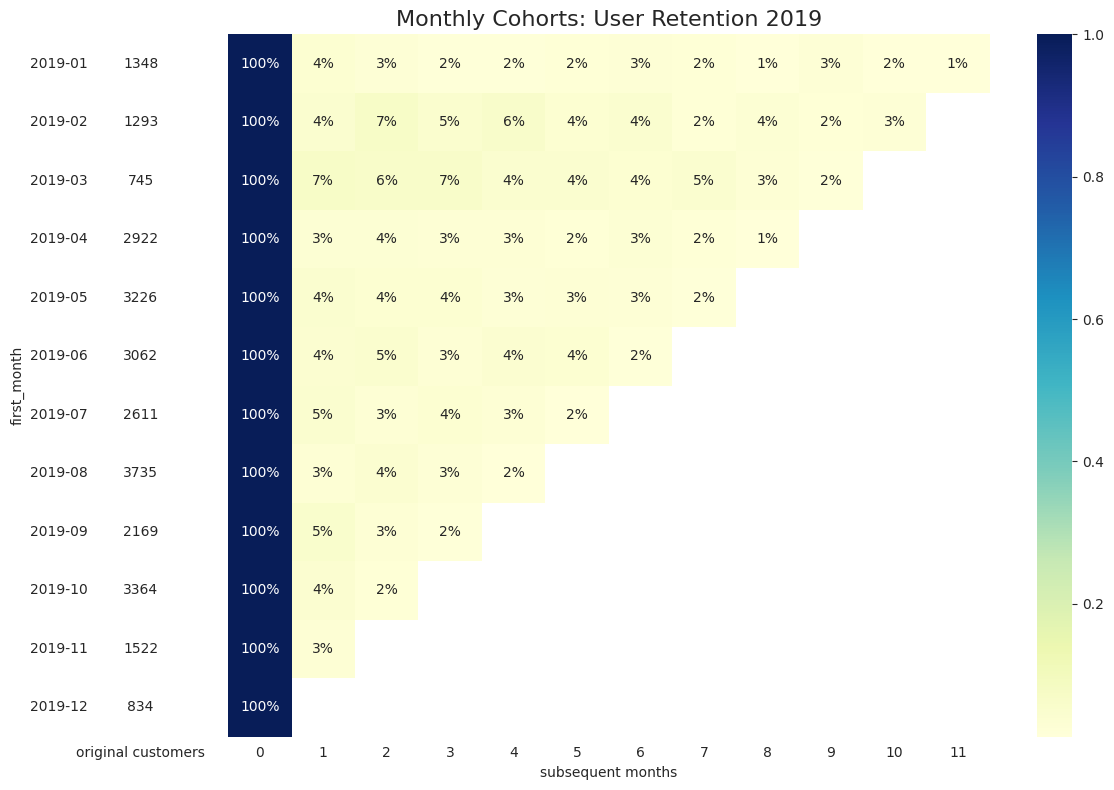

In [174]:
# Vẽ biểu đồ cohort
with sns.axes_style("white"):
    fig, ax = plt.subplots(1, 2, figsize=(12, 8), sharey=True, gridspec_kw={'width_ratios': [1, 11]})

    # retention matrix
    sns.heatmap(retention_matrix,
                mask=retention_matrix.isnull(),
                annot=True,
                fmt='.0%',
                cmap='YlGnBu',
                ax=ax[1])
    ax[1].set_title('Monthly Cohorts: User Retention 2019', fontsize=16)
    ax[1].set(xlabel='subsequent months',
              ylabel='')

    # cohort size
    cohort_size_df = pd.DataFrame(cohort_size).rename(columns={0: 'original customers'})
    white_cmap = mcolors.ListedColormap(['white'])
    sns.heatmap(cohort_size_df,
                annot=True,
                cbar=False,
                fmt='g',
                cmap=white_cmap,
                alpha=0.5,
                ax=ax[0])

    fig.tight_layout()

In [175]:
# Bước 1 : Tính toán các thông tin : cohort (first_month), current_month, subsequent month
df_selected_time = df_join_all[(df_join_all['time'] > '2022-01-01') & (df_join_all['status_id'] ==1)]
df_selected_time['first_month'] =df_selected_time.groupby('customer_id')['time'].transform('min').dt.to_period('M')
df_selected_time['current_month'] = df_selected_time['time'].dt.to_period('M')
df_selected_time['subsequent_month'] = (df_selected_time['current_month'] - df_selected_time['first_month']).apply(attrgetter('n'))

/tmp/ipykernel_4294/1114882523.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected_time['first_month'] =df_selected_time.groupby('customer_id')['time'].transform('min').dt.to_period('M')
/tmp/ipykernel_4294/1114882523.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected_time['current_month'] = df_selected_time['time'].dt.to_period('M')
/tmp/ipykernel_4294/1114882523.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_ind

In [176]:
# Bước 2: Group by cohort
df_cohor = (
    df_selected_time
    .groupby(['first_month','current_month','subsequent_month'])
    .agg(n_customers = ('customer_id','nunique'))
    .reset_index(drop = False)
)

# pivot table
df_cohort_pivot = (
    df_cohor
    .pivot_table(index = 'first_month', columns = 'subsequent_month', values = 'n_customers')
)

# Chuyển sang %
cohort_size = df_cohort_pivot.iloc[:, 0]
retention_matrix = df_cohort_pivot.divide(cohort_size, axis = 0)

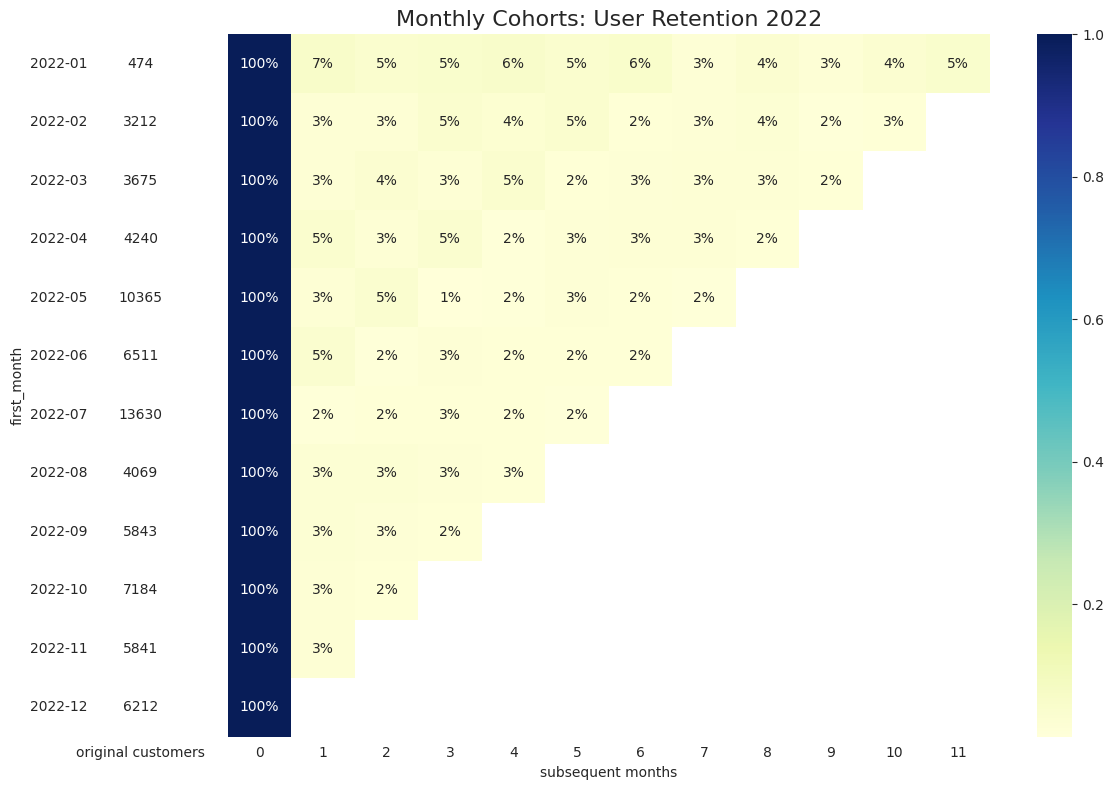

In [177]:
# Vẽ biểu đồ cohort
with sns.axes_style("white"):
    fig, ax = plt.subplots(1, 2, figsize=(12, 8), sharey=True, gridspec_kw={'width_ratios': [1, 11]})

    # retention matrix
    sns.heatmap(retention_matrix,
                mask=retention_matrix.isnull(),
                annot=True,
                fmt='.0%',
                cmap='YlGnBu',
                ax=ax[1])
    ax[1].set_title('Monthly Cohorts: User Retention 2022', fontsize=16)
    ax[1].set(xlabel='subsequent months',
              ylabel='')

    # cohort size
    cohort_size_df = pd.DataFrame(cohort_size).rename(columns={0: 'original customers'})
    white_cmap = mcolors.ListedColormap(['white'])
    sns.heatmap(cohort_size_df,
                annot=True,
                cbar=False,
                fmt='g',
                cmap=white_cmap,
                alpha=0.5,
                ax=ax[0])

    fig.tight_layout()

>**Notes:**
> - Retention 2019 và 2022 không có nhiều sự thay đổi, do thị trường phim mới hồi phục nên chưa có nhiều thời gian để công ty cải thiện
> - Lý do rentention thấp mặc dù rõ ràng 60-65% traffic có chạy promotion trong năm 2022 ?

**Compare: Retention of promotion customers & organic customers

In [178]:
# By payment method
df_pie_promo = (
    df_join_all[(df_join_all['status_id'] ==1) & (df_join_all['time'] > '2022-01-01')]
    .groupby('type')
    .agg(total_tickets = ('customer_id', 'nunique'))
).sort_values(by = 'total_tickets', ascending = True).reset_index()

In [179]:
df_pie_promo

,type,total_tickets
0,non-promotion,27672
1,promotion,47507


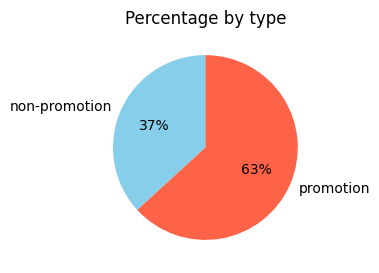

In [180]:
# pie
plt.figure(figsize = (6,3))
plt.pie(df_pie_promo['total_tickets'],
        labels = df_pie_promo['type'],
        autopct = '%1.0f%%',
        colors = df_pie_promo['type'].replace({'promotion':'tomato','non-promotion':'skyblue'}),
        startangle = 90
)
plt.title('Percentage by type')
plt.show()


In [181]:
# Phân biệt nhóm đến từ promotion và nhóm organic: dựa vào vé đầu tiên(first order)

In [182]:
# Đánh số thứ tự các ticket của khách hàng:

In [183]:
df_data_check =(
 df_join_all[(df_join_all['status_id'] ==1) & (df_join_all['time'] > '2022-01-01')][['customer_id','ticket_id','time','type']]
 .sort_values(by=['customer_id','time'])
)

In [184]:
df_data_check.head(10)

,customer_id,ticket_id,time,type
66484,100003,34c4764b4afa000af4c33a525f20eace,2022-05-22 12:52:12.105,non-promotion
10001,100004,1c4aa39842bfc83dbb5856c25a33d9cb,2022-12-20 06:26:21.373,non-promotion
108794,100007,5565ba5e22475c7cce298a2bea470428,2022-03-21 17:57:18.460,promotion
0,100009,4f5200dcdcf2396b8d50ff84bf423f32,2022-07-08 17:46:36.145,promotion
5585,100009,0724203b5146b0ebae6e3678ed7eccde,2022-12-24 09:32:45.477,promotion
69405,100013,f95441286dcfa045f61a5760662616e1,2022-05-05 12:22:44.587,non-promotion
140483,100018,1e40fb2d0f6264ed3127f79b1a12c9c9,2022-09-07 21:13:17.896,non-promotion
90595,100018,9a959ff1649950949ff2c0aff4b62205,2022-11-19 16:25:43.981,promotion
35270,100020,af02fc96a6703af7d93162d9f8c61dba,2022-05-28 19:09:37.936,promotion
16649,100023,5ed44ff62214268ffcb14d4ea78b04d8,2022-05-16 08:45:42.397,promotion


In [185]:
# Đánh só thứ tự các ticket của khách hàng:
df_data_check['row_number'] = df_data_check.groupby('customer_id').cumcount() +1

In [186]:
# Số KH có first payment là promotion:
df_data_check[(df_data_check['type'] =='promotion') & (df_data_check['row_number']==1)]['customer_id'].nunique()

46189

In [187]:
46189/47507

0.9722567200623066

In [188]:
# Có 97% KH đến từ promotion trong nhóm KH có tham gia promotion --> Retention là bao nhiêu ?

In [189]:
df_first_promo_list = df_data_check[(df_data_check['type'] =='promotion') & (df_data_check['row_number']==1)]['customer_id']
df_first_promo_list.drop_duplicates(inplace = True)

df_first_promo_check = pd.merge(df_data_check,df_first_promo_list, how = 'inner', on = 'customer_id')

/tmp/ipykernel_4294/1288125429.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_first_promo_list.drop_duplicates(inplace = True)


In [190]:
(
    df_first_promo_check[(df_first_promo_check['row_number']==2)]['customer_id'].nunique()
/
    df_first_promo_check['customer_id'].nunique()
)

0.1308969668102795

In [191]:
13# KH quay lại kể từ lần đầu tham gia promotion (tỉ lệ chuyển đổi, giữ chân KH  = 13%)

# --> Nhóm organic có khác biệt không ?

13

In [192]:
df_first_non_promo = df_data_check[(df_data_check['type'] =='non-promotion') & (df_data_check['row_number'] ==1)]['customer_id']
df_first_non_promo.drop_duplicates(inplace = True)

df_first_non_promo_check = pd.merge(df_data_check, df_first_non_promo, how = 'inner', on ='customer_id')

(
    df_first_non_promo_check[df_first_non_promo_check['row_number'] ==2]['customer_id'].nunique()
/
    df_first_non_promo_check['customer_id'].nunique()
)

/tmp/ipykernel_4294/1645405750.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_first_non_promo.drop_duplicates(inplace = True)


0.12195316551641601

In [193]:
# Nhóm KH first time là organic thì tỉ lệ quay lại là  = 12%

>**Notes:**
*  **97%** promotion 2022 là dành cho NEW CUSTOMERS, tuy nhiên
*  Chỉ có **13%** quay trở lại lân sau, trong khi tỉ lệ này của nhóm organic là **12%**


*  --> Công ty đang chú trọng acquire new customers nhưng chưa đẩy mạnh việc giữ chân và duy trì lượng KH cũ








**3.6 Payment Success rate**





**Overview**

In [194]:
def calculate_n_success (x):
  return (x==1).sum()

df_sr = (
    df_join_all
    .groupby('year_month')
    .agg(n_ords = ('ticket_id','count'), #total ticket
         n_success = ('status_id', calculate_n_success)) # success ticket
    .assign(success_rate = lambda x: (x['n_success']/x['n_ords'])*100) # tạo thêm 1 column tính SR
    .reset_index()
)

In [195]:
df_sr.head(5)

,year_month,n_ords,n_success,success_rate
0,2019-01,2019,1359,67.310550
1,2019-02,1626,1427,87.761378
2,2019-03,1004,866,86.254980
3,2019-04,4069,3190,78.397641
4,2019-05,4430,3617,81.647856


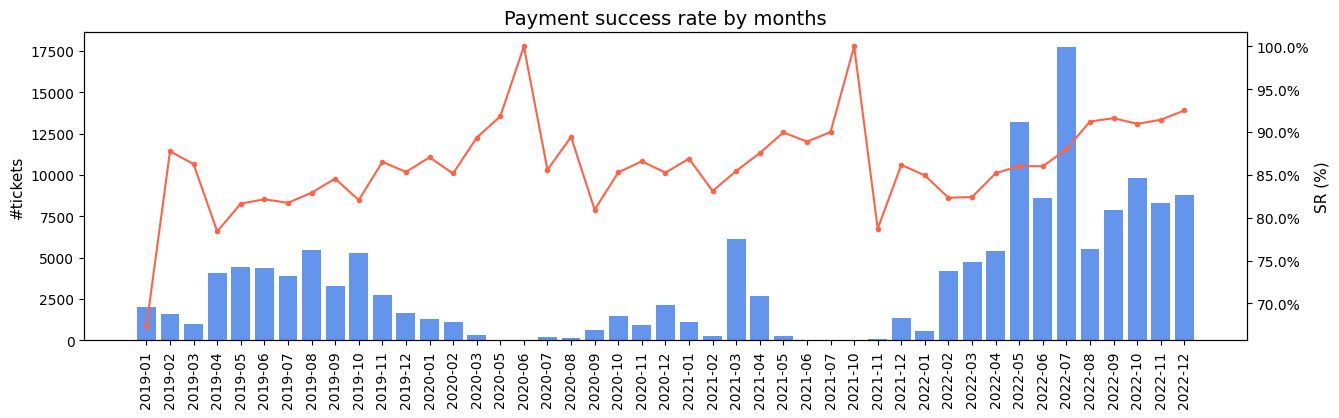

In [196]:
from matplotlib.ticker import PercentFormatter

fig, ax1 = plt.subplots(figsize = (15,4))
ax1.bar(df_sr['year_month'],df_sr['n_ords'],color = 'cornflowerblue')
plt.ylabel('#tickets', fontsize = 11)
plt.xticks(rotation = 'vertical')

ax2 = ax1.twinx()
ax2.plot(df_sr['year_month'],df_sr['success_rate'],color = 'tomato',marker = 'o',ms =3)
ax2.yaxis.set_major_formatter(PercentFormatter())

plt.ylabel('SR (%)', fontsize = 11)
plt.title('Payment success rate by months', fontsize = 14)
plt.show()

**Error Trend**

In [197]:
df_join_all.head(5)

,ticket_id,customer_id,paying_method,theater_name,device_number,original_price,discount_value,final_price,time,status_id,campaign_id,movie_name,usergender,dob,campaign_type,description,error_group,model,platform,age_days,age,month,name_day,hour,year_month,os_version,type
0,4f5200dcdcf2396b8d50ff84bf423f32,100009,money in app,13.0,244764a57dbdeb8fe9b164847ad55183,9.90,2.10,7.80,2022-07-08 17:46:36.145,1,83330,Thor: Love And Thunder,Male,1989-02-25,direct discount,Order successful,unknown,"iPhone13,1",mobile,13730,37,7,Friday,17,2022-07,ios,promotion
1,07abbaf28c772692f0367ad992bb3184,100493,bank account,180.0,8fa83cf46284aafd6e5da6c96f7862b5,8.66,1.48,7.18,2022-07-15 20:44:09.952,1,83330,Thor: Love And Thunder,Male,1991-06-09,direct discount,Order successful,unknown,browser,website,12896,35,7,Friday,20,2022-07,browser,promotion
2,1fdbeb7eceba8a27d9d985b5b70c219a,100596,money in app,56.0,69cf9244654949047f006e441fa7a8a7,10.31,2.31,8.00,2022-07-30 11:16:55.483,1,0,Thor: Love And Thunder,Male,1989-05-18,unknown,Order successful,unknown,unknown,mobile,13648,37,7,Saturday,11,2022-07,unknown,non-promotion
3,7715c9955866bd296b98543412839abd,100852,bank account,119.0,879ed11af9d6d2b5cda4d299590735a7,27.75,1.03,26.72,2022-07-04 22:33:07.458,1,85940,Thor: Love And Thunder,Male,1997-08-31,direct discount,Order successful,unknown,devicemodel,mobile,10621,29,7,Monday,22,2022-07,unknown,promotion
4,776efd7bda0b715084430e6385f67746,100965,money in app,107.0,0a233600d993a02cc1d39fb0d87fc7de,4.33,1.03,3.30,2022-07-03 18:41:45.098,1,85940,Thor: Love And Thunder,Male,1988-09-20,direct discount,Order successful,unknown,devicemodel,mobile,13888,38,7,Sunday,18,2022-07,unknown,promotion


In [198]:
# Phân bổ nhóm lỗi:
df_error_group = (
    df_join_all[df_join_all['status_id'] !=1]
    .groupby(['year_month','error_group'])
    .agg(n_ords = ('ticket_id', 'count'))
    .sort_values(by = 'year_month',ascending = True)
    .reset_index()
)

In [199]:
df_error_group.head(5)

,year_month,error_group,n_ords
0,2019-01,customer,291
1,2019-01,external,369
2,2019-02,customer,66
3,2019-02,external,133
4,2019-03,customer,44


In [200]:
df_error_group['error_group'].unique()

array(['customer', 'external', 'internal'], dtype=object)

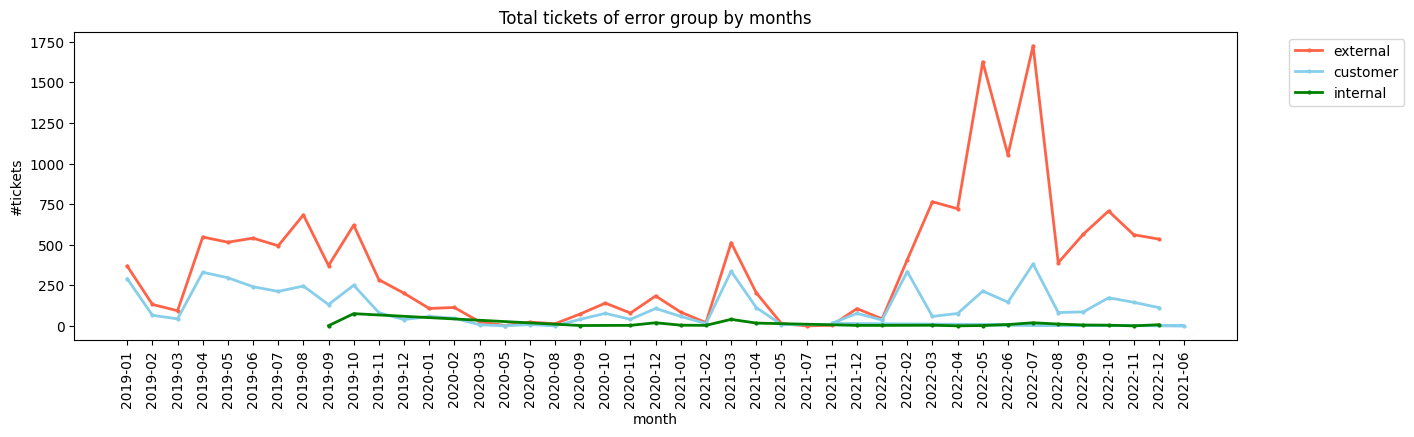

In [201]:
# Phân bổ nhóm lỗi:
error_color_pairs =[('external','tomato'),('customer','skyblue'),('internal','green')]

plt.figure(figsize = (15,4))

for error, color in error_color_pairs:
  df_err_line = df_error_group[df_error_group['error_group'] == error]
  plt.plot(df_err_line['year_month'], df_err_line['n_ords'], label =error, marker = 'o', color = color, linewidth = 2, markersize = 2)

plt.title('Total tickets of error group by months')
plt.xlabel('month')
plt.ylabel('#tickets')
plt.legend(loc = 'upper right', bbox_to_anchor = (1.15, 1))
plt.xticks(rotation = 90)
plt.show()


In [202]:
# Nhóm lỗi external tăng đột biến trong 2022 ?

In [203]:
# Phân bổ mã lỗi:
df_error = (
    df_join_all[df_join_all['status_id'] !=1]
    .groupby(['year_month','description'])
    .agg(n_ords = ('ticket_id', 'count'))
    .sort_values(by = 'year_month',ascending = True)
    .reset_index()
)

In [204]:
df_error.head(10)

,year_month,description,n_ords
0,2019-01,Insufficient funds in customer account. Please add more funds and try the transaction again.,217
1,2019-01,No response from your bank,228
2,2019-01,Password locked due to multiple incorrect attempts. Choose Forgot Password to unlock.,56
3,2019-01,Payment failed from bank,141
4,2019-01,Payment overdue,18
5,2019-02,Insufficient funds in customer account. Please add more funds and try the transaction again.,42
6,2019-02,No response from your bank,67
7,2019-02,Password locked due to multiple incorrect attempts. Choose Forgot Password to unlock.,11
8,2019-02,Payment failed from bank,66
9,2019-02,Payment overdue,13


In [205]:
df_error['description'].unique()

array(['Insufficient funds in customer account. Please add more funds and try the transaction again.',
       'No response from your bank',
       'Password locked due to multiple incorrect attempts. Choose Forgot Password to unlock.',
       'Payment failed from bank', 'Payment overdue',
       'Transaction temporarily limited',
       'Need verify your account to continue'], dtype=object)

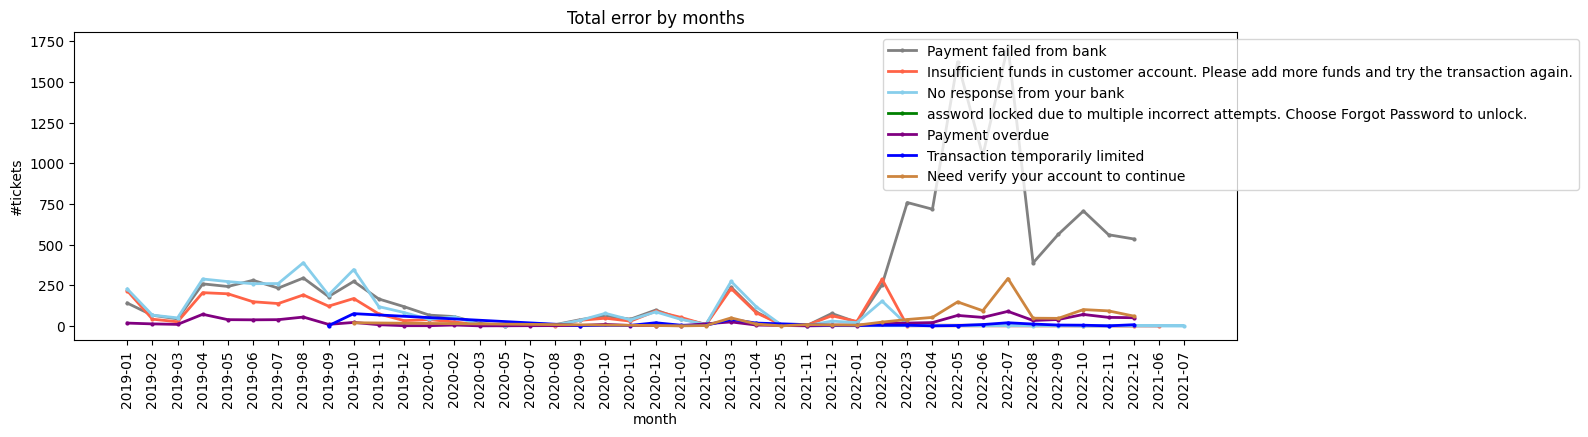

In [206]:
# Phân bổ nhóm lỗi:
error_color_pairs =[('Payment failed from bank', 'gray'),
      ('Insufficient funds in customer account. Please add more funds and try the transaction again.','tomato'),
      ('No response from your bank','skyblue'),('assword locked due to multiple incorrect attempts. Choose Forgot Password to unlock.','green'),
                    ('Payment overdue','purple') ,('Transaction temporarily limited','blue'),
                    ('Need verify your account to continue','peru')]

plt.figure(figsize = (15,4))

for error, color in error_color_pairs:
  df_err_line = df_error[df_error['description'] == error]
  plt.plot(df_err_line['year_month'], df_err_line['n_ords'], label =error, marker = 'o', color = color, linewidth = 2, markersize = 2)

plt.title('Total error by months')
plt.xlabel('month')
plt.ylabel('#tickets')
plt.legend(loc = 'upper right', bbox_to_anchor = (1.3, 1))
plt.xticks(rotation = 90)
plt.show()


In [207]:
# Lỗi đến từ bank tăng đột biến ?

**SR = 0%, why and how?**

In [208]:
list_sr_0 = list(df_customer_value[df_customer_value['success_rate'] < 0.1]['customer_id'].unique())

In [209]:
df_customer_value[df_customer_value['success_rate']< 0.1]['customer_id'].nunique()

13701

In [210]:
df_customer_value.head(5)

,customer_id,n_total,n_failed,n_success,s_money,s_discount,n_day,n_months,n_promotion,success_rate,promotion_rate,discount_rate,n_order_dis,n_promo_dis
0,100001,1,0,1.0,7.42,2.06,1.0,1.0,1.0,1.0,1.000000,0.277628,1.0,1.0
1,100003,6,0,6.0,60.95,2.56,6.0,6.0,1.0,1.0,0.166667,0.042002,6.0,1.0
2,100004,1,0,1.0,32.25,0.00,1.0,1.0,0.0,1.0,0.000000,0.000000,1.0,0.0
3,100005,1,0,1.0,9.49,2.06,1.0,1.0,1.0,1.0,1.000000,0.217071,1.0,1.0
4,100006,1,0,1.0,12.37,0.00,1.0,1.0,0.0,1.0,0.000000,0.000000,1.0,0.0


In [211]:
def calculate_n_promotion(x):
  return(x =='promotion').sum()

df_sr_0_metric = (
    df_join_all[df_join_all['customer_id'].isin(list_sr_0)]
    .groupby('customer_id')
    .agg(n_orders = ('ticket_id','count'),
         s_money = ('original_price','sum'),
         s_discount = ('discount_value', 'sum'),
         n_promotions = ('type', calculate_n_promotion)
    )
    .reset_index()
)

In [212]:
df_sr_0_metric['promotion_rate'] = df_sr_0_metric['n_promotions']/df_sr_0_metric['n_orders']
df_sr_0_metric['discount_rate'] = df_sr_0_metric['s_discount']/df_sr_0_metric['s_money']

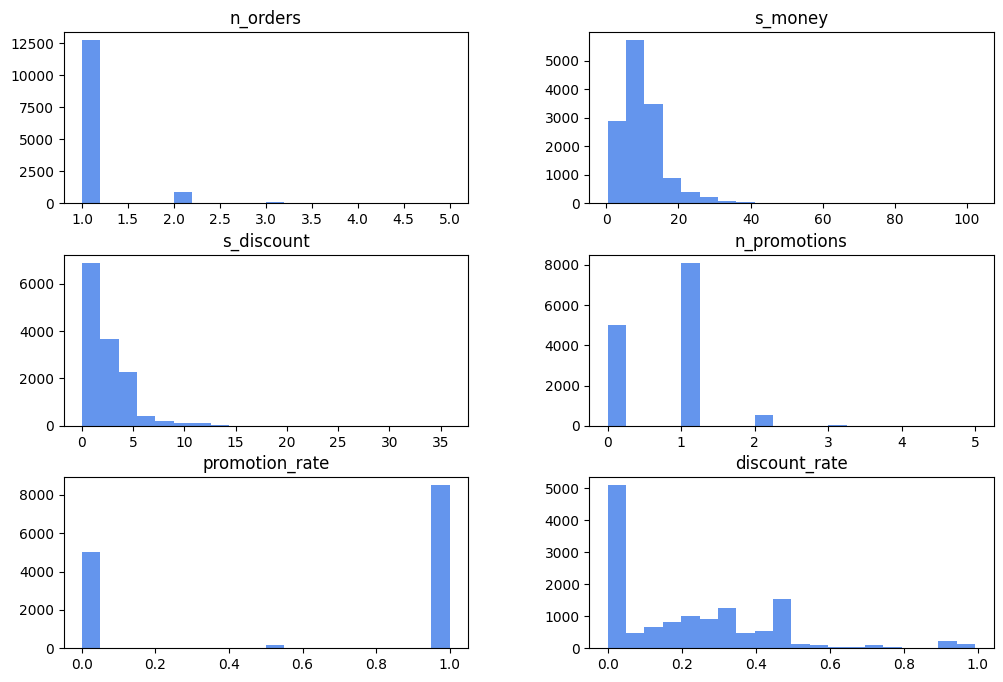

In [213]:
df_sr_0_metric.iloc[:, 1:].hist(figsize = (12,8), grid = False, color = 'cornflowerblue', bins = 20)
plt.show()

In [214]:
# Họ bị lỗi gì mà tại sao failed 1 lần và stop luôn ? Họ không retry ?

In [215]:
# Detail error:
# Phân bổ nhóm lỗi:

df_error_0 = (
    df_join_all[(df_join_all['status_id'] != 1) & (df_join_all['customer_id'].isin(list_sr_0))]
    .groupby(['year_month', 'description'])
    .agg(n_ords = ('ticket_id', 'count')
)
.sort_values(by = 'year_month', ascending = True)
.reset_index()
)


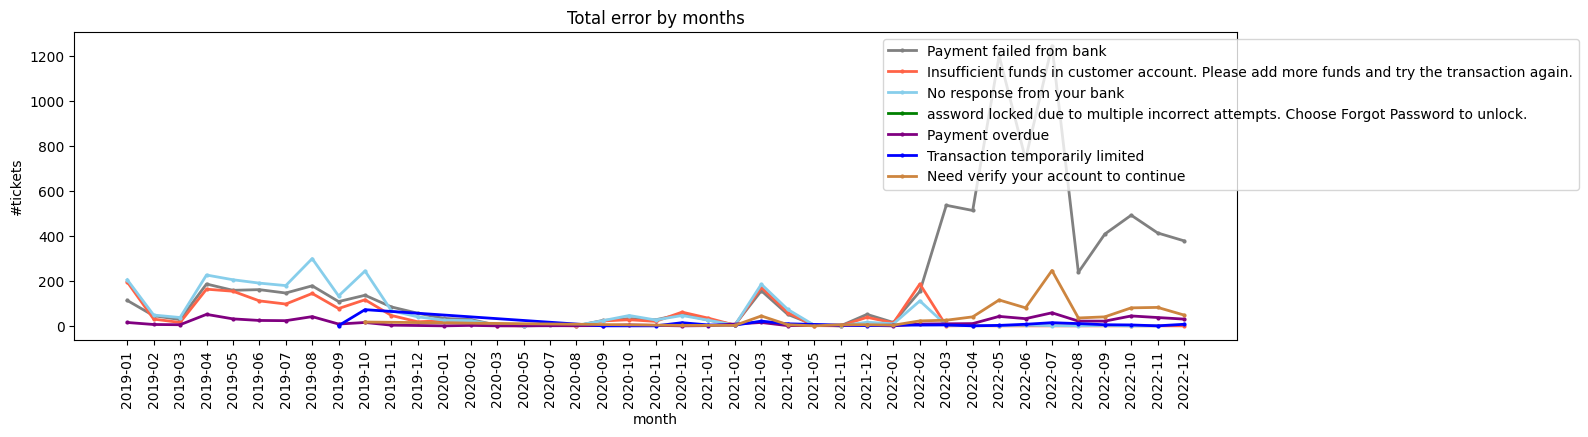

In [216]:
# Phân bổ nhóm lỗi:
error_color_pairs =[('Payment failed from bank', 'gray'),
      ('Insufficient funds in customer account. Please add more funds and try the transaction again.','tomato'),
      ('No response from your bank','skyblue'),('assword locked due to multiple incorrect attempts. Choose Forgot Password to unlock.','green'),
                    ('Payment overdue','purple') ,('Transaction temporarily limited','blue'),
                    ('Need verify your account to continue','peru')]

plt.figure(figsize = (15,4))

for error, color in error_color_pairs:
  df_err_line = df_error_0[df_error_0['description'] == error]
  plt.plot(df_err_line['year_month'], df_err_line['n_ords'], label =error, marker = 'o', color = color, linewidth = 2, markersize = 2)

plt.title('Total error by months')
plt.xlabel('month')
plt.ylabel('#tickets')
plt.legend(loc = 'upper right', bbox_to_anchor = (1.3, 1))
plt.xticks(rotation = 90)
plt.show()


>**Notes:**
*   Nhóm bị lỗi này cũng gần như là nhóm bị lỗi của toàn bộ KH(nhìn lại chart hist phía trên)
* Lý do họ lỗi và stop là do:
  1.   Lỗi bên bank và họ không chủ động được
  2.   Lỗi định danh tài khoản  --> nghi ngờ gian lận hoặc không đủ diều kiện upgrade level tài khoản




